## Evaluation of Outlier Detection Algorithms for Heart Failure Clinical Dataset

### 1. Preparation

#### 1.1. Dataset

The dataset contains the medical records of 299 patients who had heart failure. It was collected during follow-up period where each patient has 13 clinical features.<br/>The dataset was downloaded from UCI repository [here](https://archive.ics.uci.edu/dataset/519/heart+failure+clinical+records).

The performance of the following outlier detection algorithms will be evaluated on the dataset
1. Local Outlier Factor
2. Isolation Forest
3. One Class Support Vector Machine
4. Minimum Covariance Determinant
5. Density-Based Spatial Clustering of Applications with Noise (DBSCAN)

#### 1.2. Import Libraries and Dataset

In [2]:
from ucimlrepo import fetch_ucirepo
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
# Plot style
plt.style.use('ggplot')
import warnings
import seaborn as sns
from datetime import datetime
from sklearn.preprocessing import RobustScaler, MinMaxScaler, Normalizer, StandardScaler, SplineTransformer
from sklearn.metrics import RocCurveDisplay, accuracy_score, ConfusionMatrixDisplay, confusion_matrix
from sklearn.pipeline import make_pipeline
from sklearn.neighbors import LocalOutlierFactor
from sklearn.ensemble import IsolationForest
from sklearn.svm import OneClassSVM
from sklearn.covariance import EllipticEnvelope
from sklearn.cluster import DBSCAN
from sklearn.neighbors import NearestNeighbors
from sklearn.decomposition import PCA
from sklearn.metrics import roc_auc_score, roc_curve, auc, balanced_accuracy_score
from sklearn.model_selection import ParameterGrid

In [3]:
warnings.simplefilter(action='ignore', category=RuntimeWarning)
warnings.simplefilter(action='ignore', category=FutureWarning)
warnings.simplefilter(action='ignore', category=UserWarning)
warnings.simplefilter(action='ignore', category=DeprecationWarning)

pd.set_option("display.max_columns", None)
pd.set_option("display.max_rows", None)
pd.options.display.max_colwidth = None
pd.set_option("display.float_format", lambda x: '%.2f' % x)

from IPython.display import display, HTML
display(HTML("<style>.container { width:150% !important; }</style>"))

In [3]:
# Load the dataset from UCI ML Repository, including the dataframes and metadata information
heart_failure_clinical_records = fetch_ucirepo(id=519)

In [4]:
# Dataset features and targets
heart_failure_clinical_records_data = heart_failure_clinical_records.data 
# Dataset metadata
heart_failure_clinical_records_metadata = heart_failure_clinical_records.metadata
# Dataset variables
heart_failure_clinical_records_variables = heart_failure_clinical_records.variables 

In [5]:
# Dataset features and targets (as pandas dataframes)
X = heart_failure_clinical_records_data.features
y = heart_failure_clinical_records_data.targets

In [6]:
print(X.shape)
print(y.shape)

(299, 12)
(299, 1)


#### 1.3. Dataset Metadata

In [7]:
# Print varibale data type with their corresponding variable names
print(heart_failure_clinical_records_variables.type)
print(heart_failure_clinical_records_variables.name)

0        Integer
1         Binary
2        Integer
3         Binary
4        Integer
5         Binary
6     Continuous
7     Continuous
8        Integer
9         Binary
10        Binary
11       Integer
12        Binary
Name: type, dtype: object
0                          age
1                      anaemia
2     creatinine_phosphokinase
3                     diabetes
4            ejection_fraction
5          high_blood_pressure
6                    platelets
7             serum_creatinine
8                 serum_sodium
9                          sex
10                     smoking
11                        time
12                 death_event
Name: name, dtype: object


In [8]:
variable_list = list(heart_failure_clinical_records_variables.name)

In [9]:
variable_list

['age',
 'anaemia',
 'creatinine_phosphokinase',
 'diabetes',
 'ejection_fraction',
 'high_blood_pressure',
 'platelets',
 'serum_creatinine',
 'serum_sodium',
 'sex',
 'smoking',
 'time',
 'death_event']

In [10]:
# Name of the target column
print(heart_failure_clinical_records_metadata.target_col)

['death_event']


In [11]:
# Print name of the dataset
print(heart_failure_clinical_records_metadata.name)

Heart Failure Clinical Records


In [12]:
# Print subject area of the dataset
print(heart_failure_clinical_records_metadata.area)

Health and Medicine


In [13]:
# Print characteristics of the dataset
print(heart_failure_clinical_records_metadata.characteristics)

['Multivariate']


In [14]:
# Print the number of instances and features in the dataset
num_instances = heart_failure_clinical_records_metadata.num_instances
num_features = heart_failure_clinical_records_metadata.num_features
print(f'The number of instances is: {num_instances} and the number of features is: {num_features}')

The number of instances is: 299 and the number of features is: 12


In [15]:
# Has missing values?
print(heart_failure_clinical_records_metadata.has_mssing_values)

None


In [16]:
# Year of dataset creation
print(heart_failure_clinical_records_metadata.year_of_dataset_creation)

2020


In [17]:
# Dataset variable description
print(heart_failure_clinical_records_variables.description)

0                                            age of the patient
1                     decrease of red blood cells or hemoglobin
2                          level of the CPK enzyme in the blood
3                                   if the patient has diabetes
4     percentage of blood leaving the heart at each contraction
5                               if the patient has hypertension
6                                        platelets in the blood
7                        level of serum creatinine in the blood
8                            level of serum sodium in the blood
9                                                  woman or man
10                                 if the patient smokes or not
11                                             follow-up period
12              if the patient died during the follow-up period
Name: description, dtype: object


### 2. Explorative Data Analysis

#### 2.1. Inspect Dataset

In [18]:
# Combine dataset features and targets into a dataframe
df_data = pd.concat([X, y], axis=1)

In [19]:
# Check data types and missing values
df_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 299 entries, 0 to 298
Data columns (total 13 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   age                       299 non-null    float64
 1   anaemia                   299 non-null    int64  
 2   creatinine_phosphokinase  299 non-null    int64  
 3   diabetes                  299 non-null    int64  
 4   ejection_fraction         299 non-null    int64  
 5   high_blood_pressure       299 non-null    int64  
 6   platelets                 299 non-null    float64
 7   serum_creatinine          299 non-null    float64
 8   serum_sodium              299 non-null    int64  
 9   sex                       299 non-null    int64  
 10  smoking                   299 non-null    int64  
 11  time                      299 non-null    int64  
 12  death_event               299 non-null    int64  
dtypes: float64(3), int64(10)
memory usage: 30.5 KB


In [20]:
# Reset pandas to avoid scrolling through the columns
pd.reset_option('max_columns')
# Inspect first 5 records
df_data.head()

,age,anaemia,creatinine_phosphokinase,diabetes,ejection_fraction,high_blood_pressure,platelets,serum_creatinine,serum_sodium,sex,smoking,time,death_event
0,75.00,0,582,0,20,1,265000.00,1.90,130,1,0,4,1
1,55.00,0,7861,0,38,0,263358.03,1.10,136,1,0,6,1
2,65.00,0,146,0,20,0,162000.00,1.30,129,1,1,7,1
3,50.00,1,111,0,20,0,210000.00,1.90,137,1,0,7,1
4,65.00,1,160,1,20,0,327000.00,2.70,116,0,0,8,1


In [21]:
# Inspect last 5 records
df_data.tail() 

,age,anaemia,creatinine_phosphokinase,diabetes,ejection_fraction,high_blood_pressure,platelets,serum_creatinine,serum_sodium,sex,smoking,time,death_event
294,62.00,0,61,1,38,1,155000.00,1.10,143,1,1,270,0
295,55.00,0,1820,0,38,0,270000.00,1.20,139,0,0,271,0
296,45.00,0,2060,1,60,0,742000.00,0.80,138,0,0,278,0
297,45.00,0,2413,0,38,0,140000.00,1.40,140,1,1,280,0
298,50.00,0,196,0,45,0,395000.00,1.60,136,1,1,285,0


#### 2.1. Descriptive Statistics

In [22]:
# Define a list for numeric variables
numeric_variable = ['age', 'creatinine_phosphokinase', 'ejection_fraction', 'platelets', 'serum_creatinine', 'serum_sodium', 'time']

In [23]:
# Define a list for categorical variables
categorical_variable = ['anaemia', 'diabetes', 'high_blood_pressure', 'sex', 'smoking']

In [24]:
# Descriptive statistics for numeric variables
df_data[numeric_variable].describe()

,age,creatinine_phosphokinase,ejection_fraction,platelets,serum_creatinine,serum_sodium,time
count,299.00,299.00,299.00,299.00,299.00,299.00,299.00
mean,60.83,581.84,38.08,263358.03,1.39,136.63,130.26
std,11.89,970.29,11.83,97804.24,1.03,4.41,77.61
min,40.00,23.00,14.00,25100.00,0.50,113.00,4.00
25%,51.00,116.50,30.00,212500.00,0.90,134.00,73.00
50%,60.00,250.00,38.00,262000.00,1.10,137.00,115.00
75%,70.00,582.00,45.00,303500.00,1.40,140.00,203.00
max,95.00,7861.00,80.00,850000.00,9.40,148.00,285.00


In [25]:
# Function to calculate the means of numeric variables of survived and dead patients 
def numeric_variable_mean():
    for variable in numeric_variable:
        print(f"Mean {variable} of survived patients: {df_data[df_data['death_event'] == 0][variable].mean():.02f}")        
        print(f"Mean {variable} of dead patients: {df_data[df_data['death_event'] == 1][variable].mean():.02f}")
        print("\n")

In [26]:
# Print the means
numeric_variable_mean()

Mean age of survived patients: 58.76
Mean age of dead patients: 65.22


Mean creatinine_phosphokinase of survived patients: 540.05
Mean creatinine_phosphokinase of dead patients: 670.20


Mean ejection_fraction of survived patients: 40.27
Mean ejection_fraction of dead patients: 33.47


Mean platelets of survived patients: 266657.49
Mean platelets of dead patients: 256381.04


Mean serum_creatinine of survived patients: 1.18
Mean serum_creatinine of dead patients: 1.84


Mean serum_sodium of survived patients: 137.22
Mean serum_sodium of dead patients: 135.38


Mean time of survived patients: 158.34
Mean time of dead patients: 70.89




In [27]:
# Counts of all categorical variables, including the target variable - death_event
df_data[['anaemia', 'diabetes', 'high_blood_pressure', 'sex', 'smoking', 'death_event']].apply(pd.value_counts)

,anaemia,diabetes,high_blood_pressure,sex,smoking,death_event
0,170,174,194,105,203,203
1,129,125,105,194,96,96


In [28]:
# Function to count the value of categorical variables of dead and survived patients
def categorical_variable_count():
    for category in categorical_variable:
        # Count the variable with value 0
        print(f"Count of {category}: 0")
        print(f"Survived: {len(df_data[(df_data[category] == 0) & (df_data['death_event'] == 0)])}")
        print(f"Died: {len(df_data[(df_data[category] == 0) & (df_data['death_event'] == 1)])}")
        
        # Count the variable with value 1
        print(f"Count of {category}: 1")
        print(f"Survived: {len(df_data[(df_data[category] == 1) & (df_data['death_event'] == 0)])}")
        print(f"Died: {len(df_data[(df_data[category] == 1) & (df_data['death_event'] == 1)])}")
        
        print("\n")

In [29]:
# Print the counts
categorical_variable_count()

Count of anaemia: 0
Survived: 120
Died: 50
Count of anaemia: 1
Survived: 83
Died: 46


Count of diabetes: 0
Survived: 118
Died: 56
Count of diabetes: 1
Survived: 85
Died: 40


Count of high_blood_pressure: 0
Survived: 137
Died: 57
Count of high_blood_pressure: 1
Survived: 66
Died: 39


Count of sex: 0
Survived: 71
Died: 34
Count of sex: 1
Survived: 132
Died: 62


Count of smoking: 0
Survived: 137
Died: 66
Count of smoking: 1
Survived: 66
Died: 30




In [30]:
# Define class labels for the 2 distinct classes in target variable by defining a dict
class_labels = {
    0: 'Survived',
    1: 'Dead'
}
# Map the class labels and create a column for these labels
df_data['y_class'] = df_data['death_event'].map(class_labels)
df_data.iloc[:, 10:].head()

,smoking,time,death_event,y_class
0,0,4,1,Dead
1,0,6,1,Dead
2,1,7,1,Dead
3,0,7,1,Dead
4,0,8,1,Dead


In [31]:
two_distinct_classes = df_data['y_class'].unique()
class_value_counts = df_data['death_event'].value_counts(ascending=True)
print(two_distinct_classes)
print(class_value_counts)

['Dead' 'Survived']
death_event
1     96
0    203
Name: count, dtype: int64


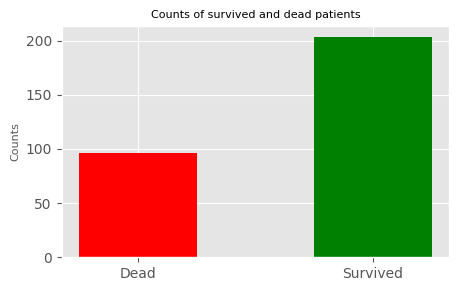

In [32]:
# Plot the counts of dead and survived patients in the dataset
plt.figure(figsize=(5, 3))
plt.bar(two_distinct_classes, class_value_counts, color=['red', 'green'], width=0.5)
plt.title('Counts of survived and dead patients', fontsize=8)
plt.ylabel('Counts', fontsize=8)
plt.show()

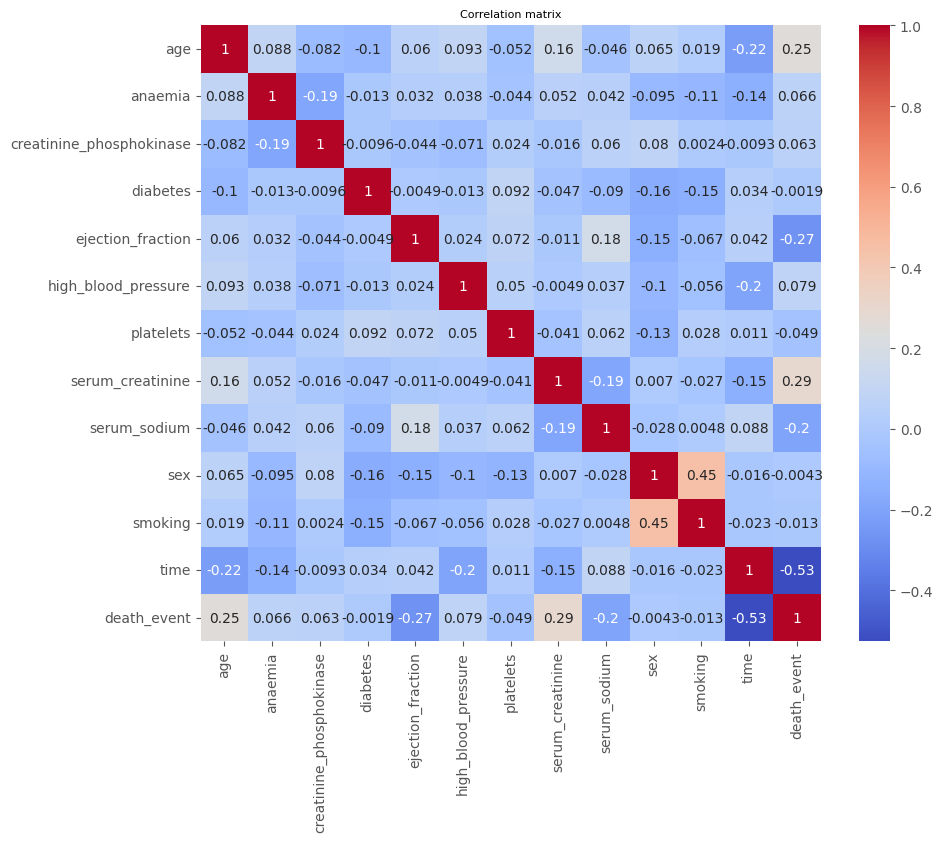

In [35]:
# Correlation matrix
corr = df_data.drop('y_class', axis=1).corr()
plt.figure(figsize=(10,8))
sns.heatmap(corr, annot=True, cmap='coolwarm')
plt.title('Correlation matrix', fontsize=8)
plt.show()

### 3. Outlier Detection Algorithms
In this section, the classical outlier detection algorithms will be used to identify the outlying data points in the dataset. These algorithms include the following:
- Local Outlier Factor (LOF)
- One Class Support Vector Machine (OneClassSVM)
- Isolation Forest (iForest)
- Minimum Covariance Determinant (MCD)

#### 3.1. Preliminaries

##### The following points should be noted concerning the dataset target y
1. y = 0 indicates survived patient
2. y = 1 indicates dead patient
3. We consider dead patients as outliers and survived patients as inliers: outliers = 1, inliers = 0

In [36]:
# Print the number and percentage of outliers in the dataset
n_samples, outlier_frac = X.to_numpy().shape[0], y.to_numpy().mean()
print(f"{n_samples} datapoints with {y.to_numpy().sum()} outliers ({outlier_frac:.02%})")

299 datapoints with 96 outliers (32.11%)


In [37]:
# Convert dataframes to numpy arrays
X = X.to_numpy()
y_true = y['death_event'].to_numpy()

In [38]:
X.shape

(299, 12)

In [39]:
y.shape

(299, 1)

In [40]:
type(y)

pandas.core.frame.DataFrame

In [41]:
type(y_true)

numpy.ndarray

In [42]:
y_true

array([1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 1, 1, 1, 1, 1, 0, 1,
       1, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 1, 1, 1, 1, 0, 1, 1, 1, 1, 0,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 0, 1, 1, 1, 1, 0, 1, 0, 1,
       1, 1, 1, 1, 0, 0, 1, 0, 1, 1, 0, 0, 0, 0, 0, 0, 1, 0, 1, 0, 0, 0,
       0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0,
       1, 0, 0, 1, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 1, 0, 1, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 1, 0, 0, 0, 1, 0, 1, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 1, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 1, 1, 1, 1, 1, 1, 1, 0, 0, 0, 0, 0, 0, 1, 1, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 1, 0, 0,
       1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0,
       0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0])

In [43]:
# Preprocessing methods
# None means no preprocessing
preprocessor_list = [
    None,
    StandardScaler(),
    RobustScaler(),
    MinMaxScaler(),
    Normalizer(),
    SplineTransformer()
]

#### 3.2. Explained Variance and PCA for 2-D Visualization

In [44]:
# Fit PCA with the data to return an object
X_pca = PCA(n_components=2).fit(X)

In [45]:
# Get the explained variance ratio of the principal components
X_pca.explained_variance_ratio_

array([9.99900987e-01, 9.83521116e-05])

- It can be seen that the first principal component accounts for most of the variability in the data (99.9 %), <br> and thus most of the information in the data is retained in this principal component.

In [46]:
# Actual variance in the data
X_pca.explained_variance_

array([9.56566931e+09, 9.40896938e+05])

In [47]:
# To visualize the data in 2-D space, transform the data using PCA
X_reduced = PCA(n_components=2).fit_transform(X)
# Convert the PCA data to a dataframe
X_reduced_df = pd.DataFrame(data=X_reduced, columns=['PC1', 'PC2'])
# Convert the PCA data to a dataframe for PCA effect
# X_reduced_pca_df = pd.DataFrame(data=X_reduced, columns=['PC1', 'PC2'])

In [48]:
X_reduced_df.shape

(299, 2)

In [49]:
X_reduced_df.head()

,PC1,PC2
0,1641.97,-0.15
1,1.77,7279.25
2,-101358.13,-411.14
3,-53358.14,-457.77
4,63641.87,-437.19


In [50]:
# Include the target in the dataframe
X_reduced_df['y'] = y
X_reduced_df['outlier'] = y.replace([1, 0], ["Yes", "No"])

In [51]:
X_reduced_df.head()

,PC1,PC2,y,outlier
0,1641.97,-0.15,1,Yes
1,1.77,7279.25,1,Yes
2,-101358.13,-411.14,1,Yes
3,-53358.14,-457.77,1,Yes
4,63641.87,-437.19,1,Yes


In [52]:
# Function for 2-D scatter plot of the data
def outlier_scatter_plot(X_reduced_df, outlier_column, model_name=None):
    plt.figure(figsize=(6, 4))

    plt.scatter(X_reduced_df[X_reduced_df[outlier_column]=="No"]['PC1'], 
                    X_reduced_df[X_reduced_df[outlier_column]=="No"]['PC2'], 
                    c='black',
                    s=5*3,
                    label='Survived: Inliers')
    
    plt.scatter(X_reduced_df[X_reduced_df[outlier_column]=="Yes"]['PC1'], 
                    X_reduced_df[X_reduced_df[outlier_column]=="Yes"]['PC2'], 
                    c='red',
                    s=5*3,
                    label='Died: Outliers')

    if model_name is None:
        plt.title("Heart failure clinical dataset (inliers vs outliers)", fontsize=8)

    else:
        plt.title(f"{model_name} (inliers vs outliers)", fontsize=8)
    plt.legend(shadow=True, fontsize=6)
    plt.xlabel("PC1", fontsize=8)
    plt.ylabel("PC2", fontsize=8)

In [53]:
# # Function for 2-D scatter plot of the data
# def outlier_scatter_plot(X_reduced_df, outlier_column, outlier_score_column='None', model_name='None'):
#     plt.figure(figsize=(8, 6))
#     if outlier_score_column=='None' and model_name=='None':
#         plt.scatter(X_reduced_df[X_reduced_df[outlier_column]=="No"]['PC1'], 
#                     X_reduced_df[X_reduced_df[outlier_column]=="No"]['PC2'], 
#                     c='black',
#                     s=5*3,
#                     label='Died: No (Inliers)')
    
#         plt.scatter(X_reduced_df[X_reduced_df[outlier_column]=="Yes"]['PC1'], 
#                     X_reduced_df[X_reduced_df[outlier_column]=="Yes"]['PC2'], 
#                     c='red',
#                     s=5*3,
#                     label='Died: Yes (Outliers)')
#         plt.title("Heart failure clinical dataset (inliers vs outliers)", fontsize=12)
        
#     else:
#         plt.scatter(X_reduced_df[X_reduced_df[outlier_column]=="No"]['PC1'],
#                     X_reduced_df[X_reduced_df[outlier_column]=="No"]['PC2'],
#                     c=X_reduced_df[X_reduced_df[outlier_column]=="No"][outlier_score_column],
#                     cmap="magma",
#                     s=5*3,
#                     label='Died: No (Inliers)',
#                     alpha=0.6)

#         plt.scatter(X_reduced_df[X_reduced_df[outlier_column]=="Yes"]['PC1'],
#                     X_reduced_df[X_reduced_df[outlier_column]=="Yes"]['PC2'],
#                     c=X_reduced_df[X_reduced_df[outlier_column]=="Yes"][outlier_score_column],
#                     cmap="magma",
#                     s=5*6,
#                     label='Died: Yes (Outliers)',
#                     marker="d",
#                     alpha=0.6)
#         plt.title(f"{model_name} (inliers vs outliers)", fontsize=12)
#         plt.colorbar(label="Outlier Scores")
#     #plt.xscale('log')
#     #plt.yscale('log')
#     plt.legend(shadow=True, fontsize=7)
#     plt.xlabel("PC1")
#     plt.ylabel("PC2")
    

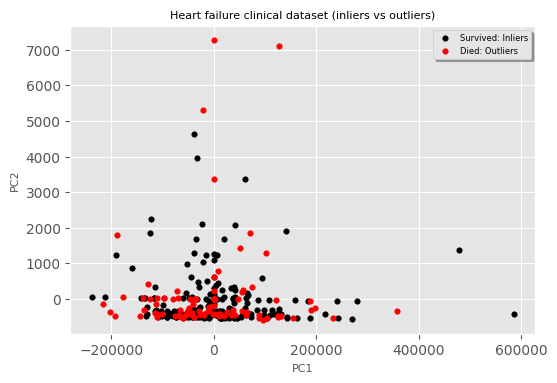

In [54]:
outlier_scatter_plot(X_reduced_df, 'outlier')

#### 3.3. Hyperparameter Tuning

The hyperparameters of the outlier detection models need to be tuned to identify and select the optimal hyperparameters that will be used in training the models. At the same time, the following scaling methods are combined with these hyperparameters to identify the optimal scaling methods for the data.

- None - means no preprocessing
- StandardScaler
- RobustScaler
- MinMaxScaler
- SplineTransformer
- Normalizer
  
<b> The following two points should be noted in all of the ROC curve plots

- The inliers (class label 1) belongs to the negative class
- The outliers (class label 0) belongs to the positive class

#### 3.3.1. Local Outlier Factor

In [55]:
# LOF parameters and parameter grid
n_neighbors_values = (n_samples * np.array([0.5, 0.45, 0.35, 0.3211, 0.2, 0.1, 0.067])).astype(np.int32)
p_values = [1, 2]
lof_params = {'scaler': preprocessor_list, 'n_neighbors': n_neighbors_values, 'p': p_values}

# Define parameter grid
lof_param_grid = ParameterGrid(lof_params)

In [56]:
len(list(lof_param_grid))

84

In [57]:
list(lof_param_grid)[:10]

[{'n_neighbors': np.int32(149), 'p': 1, 'scaler': None},
 {'n_neighbors': np.int32(149), 'p': 1, 'scaler': StandardScaler()},
 {'n_neighbors': np.int32(149), 'p': 1, 'scaler': RobustScaler()},
 {'n_neighbors': np.int32(149), 'p': 1, 'scaler': MinMaxScaler()},
 {'n_neighbors': np.int32(149), 'p': 1, 'scaler': Normalizer()},
 {'n_neighbors': np.int32(149), 'p': 1, 'scaler': SplineTransformer()},
 {'n_neighbors': np.int32(149), 'p': 2, 'scaler': None},
 {'n_neighbors': np.int32(149), 'p': 2, 'scaler': StandardScaler()},
 {'n_neighbors': np.int32(149), 'p': 2, 'scaler': RobustScaler()},
 {'n_neighbors': np.int32(149), 'p': 2, 'scaler': MinMaxScaler()}]

In [58]:
lof_best_rocauc_score = -1
lof_best_params = {}
lof_params_metric_scores = []

# Start time 
start_time = datetime.now()

for params in lof_param_grid:
    scaler = params['scaler']
    n_neighbors = params['n_neighbors']
    p = params['p']
    
    lof = LocalOutlierFactor(n_neighbors=n_neighbors, p=p, contamination=outlier_frac, n_jobs=-1)

    if scaler is None:
        model = make_pipeline(lof)
    else:
        model = make_pipeline(scaler, lof)
        
    model.fit(X)
    y_scores = model[-1].negative_outlier_factor_
    fpr, tpr, thresholds = roc_curve(y_true, y_scores, pos_label=0)
    auc_score = auc(fpr, tpr)
    #params = {'scaler': scaler, 'n_neighbors': n_neighbors, 'p': p}
    # Add new key-value pair using dictionary unpacking
    lof_params_metric_scores.append({**params, 'auc_score': auc_score})
    
    if auc_score > lof_best_rocauc_score:
        lof_best_rocauc_score = auc_score
        lof_best_params = params

# End time 
end_time = datetime.now()
runtime_duration = end_time - start_time
print(f"Runtime: {runtime_duration.total_seconds()} seconds")
print(f"LOF best rocauc score: {lof_best_rocauc_score}")
print(f"LOF best parameters: {lof_best_params}")

Runtime: 3.277663 seconds
LOF best rocauc score: 0.7474343185550082
LOF best parameters: {'n_neighbors': np.int32(20), 'p': 1, 'scaler': SplineTransformer()}


In [59]:
# Sort in descending order according to roc-auc score 
lof_params_metric_scores.sort(key=lambda x: x['auc_score'], reverse=True)

In [60]:
lof_params_metric_scores[:10]

[{'n_neighbors': np.int32(20),
  'p': 1,
  'scaler': SplineTransformer(),
  'auc_score': np.float64(0.7474343185550082)},
 {'n_neighbors': np.int32(29),
  'p': 1,
  'scaler': SplineTransformer(),
  'auc_score': np.float64(0.7392241379310346)},
 {'n_neighbors': np.int32(29),
  'p': 1,
  'scaler': MinMaxScaler(),
  'auc_score': np.float64(0.7285509031198687)},
 {'n_neighbors': np.int32(59),
  'p': 1,
  'scaler': StandardScaler(),
  'auc_score': np.float64(0.7276272577996715)},
 {'n_neighbors': np.int32(20),
  'p': 1,
  'scaler': StandardScaler(),
  'auc_score': np.float64(0.725933908045977)},
 {'n_neighbors': np.int32(149),
  'p': 1,
  'scaler': RobustScaler(),
  'auc_score': np.float64(0.725369458128079)},
 {'n_neighbors': np.int32(134),
  'p': 1,
  'scaler': RobustScaler(),
  'auc_score': np.float64(0.7242405582922825)},
 {'n_neighbors': np.int32(29),
  'p': 1,
  'scaler': StandardScaler(),
  'auc_score': np.float64(0.7216235632183908)},
 {'n_neighbors': np.int32(96),
  'p': 1,
  'scal

In [61]:
len(lof_params_metric_scores)

84

In [62]:
# Get the best hyperparater values for SplineTransformer
lof_spline_params_metric_scores = [s for s in lof_params_metric_scores if str(s['scaler']) == 'SplineTransformer()']

In [63]:
lof_spline_params_metric_scores[:5]

[{'n_neighbors': np.int32(20),
  'p': 1,
  'scaler': SplineTransformer(),
  'auc_score': np.float64(0.7474343185550082)},
 {'n_neighbors': np.int32(29),
  'p': 1,
  'scaler': SplineTransformer(),
  'auc_score': np.float64(0.7392241379310346)},
 {'n_neighbors': np.int32(59),
  'p': 1,
  'scaler': SplineTransformer(),
  'auc_score': np.float64(0.7159277504105089)},
 {'n_neighbors': np.int32(20),
  'p': 2,
  'scaler': SplineTransformer(),
  'auc_score': np.float64(0.715311986863711)},
 {'n_neighbors': np.int32(29),
  'p': 2,
  'scaler': SplineTransformer(),
  'auc_score': np.float64(0.707820197044335)}]

In [64]:
len(lof_spline_params_metric_scores)

14

In [65]:
# Get the best hyperparater values for None
lof_none_params_metric_scores = [s for s in lof_params_metric_scores if str(s['scaler']) == 'None']

In [66]:
lof_none_params_metric_scores[:5]

[{'n_neighbors': np.int32(134),
  'p': 1,
  'scaler': None,
  'auc_score': np.float64(0.5645525451559934)},
 {'n_neighbors': np.int32(149),
  'p': 2,
  'scaler': None,
  'auc_score': np.float64(0.5632183908045977)},
 {'n_neighbors': np.int32(149),
  'p': 1,
  'scaler': None,
  'auc_score': np.float64(0.5626539408866995)},
 {'n_neighbors': np.int32(134),
  'p': 2,
  'scaler': None,
  'auc_score': np.float64(0.5621408045977012)},
 {'n_neighbors': np.int32(104),
  'p': 1,
  'scaler': None,
  'auc_score': np.float64(0.5526477832512315)}]

In [67]:
len(lof_none_params_metric_scores)

14

In [68]:
# Get the best hyperparater values for StandardScaler
lof_standard_params_metric_scores = [s for s in lof_params_metric_scores if str(s['scaler']) == 'StandardScaler()']

In [69]:
lof_standard_params_metric_scores[:5]

[{'n_neighbors': np.int32(59),
  'p': 1,
  'scaler': StandardScaler(),
  'auc_score': np.float64(0.7276272577996715)},
 {'n_neighbors': np.int32(20),
  'p': 1,
  'scaler': StandardScaler(),
  'auc_score': np.float64(0.725933908045977)},
 {'n_neighbors': np.int32(29),
  'p': 1,
  'scaler': StandardScaler(),
  'auc_score': np.float64(0.7216235632183908)},
 {'n_neighbors': np.int32(96),
  'p': 1,
  'scaler': StandardScaler(),
  'auc_score': np.float64(0.7140804597701149)},
 {'n_neighbors': np.int32(104),
  'p': 1,
  'scaler': StandardScaler(),
  'auc_score': np.float64(0.7126949917898194)}]

In [70]:
len(lof_standard_params_metric_scores)

14

In [71]:
# Get the best hyperparater values for RobustScaler
lof_robust_params_metric_scores = [s for s in lof_params_metric_scores if str(s['scaler']) == 'RobustScaler()']

In [72]:
lof_robust_params_metric_scores[:5]

[{'n_neighbors': np.int32(149),
  'p': 1,
  'scaler': RobustScaler(),
  'auc_score': np.float64(0.725369458128079)},
 {'n_neighbors': np.int32(134),
  'p': 1,
  'scaler': RobustScaler(),
  'auc_score': np.float64(0.7242405582922825)},
 {'n_neighbors': np.int32(96),
  'p': 1,
  'scaler': RobustScaler(),
  'auc_score': np.float64(0.7178776683087029)},
 {'n_neighbors': np.int32(104),
  'p': 1,
  'scaler': RobustScaler(),
  'auc_score': np.float64(0.7176724137931035)},
 {'n_neighbors': np.int32(59),
  'p': 1,
  'scaler': RobustScaler(),
  'auc_score': np.float64(0.7072044334975368)}]

In [73]:
len(lof_robust_params_metric_scores)

14

In [74]:
# Get the best hyperparater values for MinMaxScaler
lof_minmax_params_metric_scores = [s for s in lof_params_metric_scores if str(s['scaler']) == 'MinMaxScaler()']

In [75]:
lof_minmax_params_metric_scores[:5]

[{'n_neighbors': np.int32(29),
  'p': 1,
  'scaler': MinMaxScaler(),
  'auc_score': np.float64(0.7285509031198687)},
 {'n_neighbors': np.int32(20),
  'p': 1,
  'scaler': MinMaxScaler(),
  'auc_score': np.float64(0.7017138752052545)},
 {'n_neighbors': np.int32(59),
  'p': 1,
  'scaler': MinMaxScaler(),
  'auc_score': np.float64(0.6657430213464697)},
 {'n_neighbors': np.int32(29),
  'p': 2,
  'scaler': MinMaxScaler(),
  'auc_score': np.float64(0.6636391625615763)},
 {'n_neighbors': np.int32(20),
  'p': 2,
  'scaler': MinMaxScaler(),
  'auc_score': np.float64(0.6454741379310345)}]

In [76]:
len(lof_minmax_params_metric_scores)

14

In [77]:
# Get the best hyperparater values for Normalizer
lof_normalizer_params_metric_scores = [s for s in lof_params_metric_scores if str(s['scaler']) == 'Normalizer()']

In [78]:
lof_normalizer_params_metric_scores[:5]

[{'n_neighbors': np.int32(20),
  'p': 2,
  'scaler': Normalizer(),
  'auc_score': np.float64(0.5621921182266011)},
 {'n_neighbors': np.int32(29),
  'p': 1,
  'scaler': Normalizer(),
  'auc_score': np.float64(0.5611145320197044)},
 {'n_neighbors': np.int32(29),
  'p': 2,
  'scaler': Normalizer(),
  'auc_score': np.float64(0.5605500821018061)},
 {'n_neighbors': np.int32(20),
  'p': 1,
  'scaler': Normalizer(),
  'auc_score': np.float64(0.559061986863711)},
 {'n_neighbors': np.int32(96),
  'p': 2,
  'scaler': Normalizer(),
  'auc_score': np.float64(0.5471059113300494)}]

In [79]:
len(lof_normalizer_params_metric_scores)

14

#### 3.3.2. Isolation Forest

In [80]:
# iForest parameters and parameter grid
n_estimators_values = [100, 150, 200, 250, 300, 350, 400]
max_samples_values = ["auto", 0.6, 0.65, 0.7, 0.8, 0.85, 0.9, 0.95, 1.0]
max_features_values = [0.6, 0.8, 0.9, 1.0]
isf_params = { 'scaler': preprocessor_list, 'n_estimators': n_estimators_values, 'max_samples': max_samples_values, 
              'max_features': max_features_values}

# Define parameter grid
isf_param_grid = ParameterGrid(isf_params)

In [81]:
len(list(isf_param_grid))

1512

In [82]:
list(isf_param_grid)[:10]

[{'max_features': 0.6,
  'max_samples': 'auto',
  'n_estimators': 100,
  'scaler': None},
 {'max_features': 0.6,
  'max_samples': 'auto',
  'n_estimators': 100,
  'scaler': StandardScaler()},
 {'max_features': 0.6,
  'max_samples': 'auto',
  'n_estimators': 100,
  'scaler': RobustScaler()},
 {'max_features': 0.6,
  'max_samples': 'auto',
  'n_estimators': 100,
  'scaler': MinMaxScaler()},
 {'max_features': 0.6,
  'max_samples': 'auto',
  'n_estimators': 100,
  'scaler': Normalizer()},
 {'max_features': 0.6,
  'max_samples': 'auto',
  'n_estimators': 100,
  'scaler': SplineTransformer()},
 {'max_features': 0.6,
  'max_samples': 'auto',
  'n_estimators': 150,
  'scaler': None},
 {'max_features': 0.6,
  'max_samples': 'auto',
  'n_estimators': 150,
  'scaler': StandardScaler()},
 {'max_features': 0.6,
  'max_samples': 'auto',
  'n_estimators': 150,
  'scaler': RobustScaler()},
 {'max_features': 0.6,
  'max_samples': 'auto',
  'n_estimators': 150,
  'scaler': MinMaxScaler()}]

In [83]:
isf_best_rocauc_score = -1
isf_best_params = {}
isf_params_metric_scores = []

# Start time 
start_time = datetime.now()

for params in isf_param_grid:
    scaler = params['scaler']
    n_estimators = params['n_estimators']
    max_samples = params['max_samples']
    max_features = params['max_features']
    isf = IsolationForest(n_estimators=n_estimators, max_samples=max_samples, contamination=outlier_frac, 
                          max_features=max_features, random_state=42, n_jobs=-1)

    if scaler is None:
        model = make_pipeline(isf)
    else:
        model = make_pipeline(scaler, isf)
        
    model.fit(X)
    y_scores = model.decision_function(X)
    fpr, tpr, thresholds = roc_curve(y_true, y_scores, pos_label=0)
    auc_score = auc(fpr, tpr)
    #params = {'scaler': scaler, 'n_estimators': n_estimators, 'max_samples': max_samples, 'max_features':max_features}
    # Add new key-value pair using dictionary unpacking
    isf_params_metric_scores.append({**params, 'auc_score': auc_score})
    
    if auc_score > isf_best_rocauc_score:
        isf_best_rocauc_score = auc_score
        isf_best_params = params

# End time 
end_time = datetime.now()
runtime_duration = end_time - start_time
print(f"Runtime: {runtime_duration.total_seconds()} seconds")
print(f"iForest best rocauc score: {isf_best_rocauc_score}")
print(f"iForest best parameters: {isf_best_params}")

Runtime: 1089.454443 seconds
iForest best rocauc score: 0.7345545977011494
iForest best parameters: {'max_features': 0.9, 'max_samples': 0.65, 'n_estimators': 100, 'scaler': None}


In [84]:
# Sort in descending order according to roc-auc score
isf_params_metric_scores.sort(key=lambda x: x['auc_score'], reverse=True)

In [85]:
isf_params_metric_scores[:10]

[{'max_features': 0.9,
  'max_samples': 0.65,
  'n_estimators': 100,
  'scaler': None,
  'auc_score': np.float64(0.7345545977011494)},
 {'max_features': 0.9,
  'max_samples': 0.65,
  'n_estimators': 100,
  'scaler': StandardScaler(),
  'auc_score': np.float64(0.7345545977011494)},
 {'max_features': 0.9,
  'max_samples': 0.65,
  'n_estimators': 100,
  'scaler': RobustScaler(),
  'auc_score': np.float64(0.7345545977011494)},
 {'max_features': 0.9,
  'max_samples': 0.65,
  'n_estimators': 100,
  'scaler': MinMaxScaler(),
  'auc_score': np.float64(0.7345545977011494)},
 {'max_features': 0.6,
  'max_samples': 0.6,
  'n_estimators': 150,
  'scaler': SplineTransformer(),
  'auc_score': np.float64(0.7309113300492611)},
 {'max_features': 0.8,
  'max_samples': 0.7,
  'n_estimators': 100,
  'scaler': None,
  'auc_score': np.float64(0.7309113300492611)},
 {'max_features': 0.8,
  'max_samples': 0.7,
  'n_estimators': 100,
  'scaler': StandardScaler(),
  'auc_score': np.float64(0.7309113300492611)},

In [86]:
len(isf_params_metric_scores)

1512

In [87]:
# Get the best hyperparater values for None
isf_none_params_metric_scores = [s for s in isf_params_metric_scores if str(s['scaler']) == 'None']

In [88]:
isf_none_params_metric_scores[:5]

[{'max_features': 0.9,
  'max_samples': 0.65,
  'n_estimators': 100,
  'scaler': None,
  'auc_score': np.float64(0.7345545977011494)},
 {'max_features': 0.8,
  'max_samples': 0.7,
  'n_estimators': 100,
  'scaler': None,
  'auc_score': np.float64(0.7309113300492611)},
 {'max_features': 0.9,
  'max_samples': 0.7,
  'n_estimators': 100,
  'scaler': None,
  'auc_score': np.float64(0.7263444170771757)},
 {'max_features': 0.9,
  'max_samples': 0.7,
  'n_estimators': 150,
  'scaler': None,
  'auc_score': np.float64(0.7241892446633826)},
 {'max_features': 0.9,
  'max_samples': 0.6,
  'n_estimators': 100,
  'scaler': None,
  'auc_score': np.float64(0.7233169129720854)}]

In [89]:
len(isf_none_params_metric_scores)

252

In [90]:
# Get the best hyperparater values for StandardScaler
isf_standard_params_metric_scores = [s for s in isf_params_metric_scores if str(s['scaler']) == 'StandardScaler()']

In [91]:
isf_standard_params_metric_scores[:5]

[{'max_features': 0.9,
  'max_samples': 0.65,
  'n_estimators': 100,
  'scaler': StandardScaler(),
  'auc_score': np.float64(0.7345545977011494)},
 {'max_features': 0.8,
  'max_samples': 0.7,
  'n_estimators': 100,
  'scaler': StandardScaler(),
  'auc_score': np.float64(0.7309113300492611)},
 {'max_features': 0.9,
  'max_samples': 0.7,
  'n_estimators': 100,
  'scaler': StandardScaler(),
  'auc_score': np.float64(0.7263444170771757)},
 {'max_features': 0.9,
  'max_samples': 0.7,
  'n_estimators': 150,
  'scaler': StandardScaler(),
  'auc_score': np.float64(0.7241892446633826)},
 {'max_features': 0.9,
  'max_samples': 0.6,
  'n_estimators': 100,
  'scaler': StandardScaler(),
  'auc_score': np.float64(0.7233169129720854)}]

In [92]:
len(isf_standard_params_metric_scores)

252

In [93]:
# Get the best hyperparater values for RobustScaler
isf_robust_params_metric_scores = [s for s in isf_params_metric_scores if str(s['scaler']) == 'RobustScaler()']

In [94]:
isf_robust_params_metric_scores[:5]

[{'max_features': 0.9,
  'max_samples': 0.65,
  'n_estimators': 100,
  'scaler': RobustScaler(),
  'auc_score': np.float64(0.7345545977011494)},
 {'max_features': 0.8,
  'max_samples': 0.7,
  'n_estimators': 100,
  'scaler': RobustScaler(),
  'auc_score': np.float64(0.7309113300492611)},
 {'max_features': 0.9,
  'max_samples': 0.7,
  'n_estimators': 100,
  'scaler': RobustScaler(),
  'auc_score': np.float64(0.7263444170771757)},
 {'max_features': 0.9,
  'max_samples': 0.7,
  'n_estimators': 150,
  'scaler': RobustScaler(),
  'auc_score': np.float64(0.7241892446633826)},
 {'max_features': 0.9,
  'max_samples': 0.6,
  'n_estimators': 100,
  'scaler': RobustScaler(),
  'auc_score': np.float64(0.7233169129720854)}]

In [95]:
len(isf_robust_params_metric_scores)

252

In [96]:
# Get the best hyperparater values for MinMaxScaler
isf_minmax_params_metric_scores = [s for s in isf_params_metric_scores if str(s['scaler']) == 'MinMaxScaler()']

In [97]:
isf_minmax_params_metric_scores[:5]

[{'max_features': 0.9,
  'max_samples': 0.65,
  'n_estimators': 100,
  'scaler': MinMaxScaler(),
  'auc_score': np.float64(0.7345545977011494)},
 {'max_features': 0.8,
  'max_samples': 0.7,
  'n_estimators': 100,
  'scaler': MinMaxScaler(),
  'auc_score': np.float64(0.7309113300492611)},
 {'max_features': 0.9,
  'max_samples': 0.7,
  'n_estimators': 100,
  'scaler': MinMaxScaler(),
  'auc_score': np.float64(0.7263444170771757)},
 {'max_features': 0.9,
  'max_samples': 0.7,
  'n_estimators': 150,
  'scaler': MinMaxScaler(),
  'auc_score': np.float64(0.7241892446633826)},
 {'max_features': 0.9,
  'max_samples': 0.6,
  'n_estimators': 100,
  'scaler': MinMaxScaler(),
  'auc_score': np.float64(0.7233169129720854)}]

In [98]:
len(isf_minmax_params_metric_scores)

252

In [99]:
# Get the best hyperparater values for Normalizer
isf_normalizer_params_metric_scores = [s for s in isf_params_metric_scores if str(s['scaler']) == 'Normalizer()']

In [100]:
isf_normalizer_params_metric_scores[:5]

[{'max_features': 1.0,
  'max_samples': 0.9,
  'n_estimators': 150,
  'scaler': Normalizer(),
  'auc_score': np.float64(0.6479885057471264)},
 {'max_features': 1.0,
  'max_samples': 1.0,
  'n_estimators': 150,
  'scaler': Normalizer(),
  'auc_score': np.float64(0.6451662561576353)},
 {'max_features': 1.0,
  'max_samples': 0.9,
  'n_estimators': 200,
  'scaler': Normalizer(),
  'auc_score': np.float64(0.6451149425287357)},
 {'max_features': 0.6,
  'max_samples': 'auto',
  'n_estimators': 250,
  'scaler': Normalizer(),
  'auc_score': np.float64(0.6447557471264367)},
 {'max_features': 0.6,
  'max_samples': 0.85,
  'n_estimators': 200,
  'scaler': Normalizer(),
  'auc_score': np.float64(0.6444991789819375)}]

In [101]:
len(isf_normalizer_params_metric_scores)

252

In [102]:
# Get the best hyperparater values for SplineTransformer
isf_spline_params_metric_scores = [s for s in isf_params_metric_scores if str(s['scaler']) == 'SplineTransformer()']

In [103]:
isf_spline_params_metric_scores[:5]

[{'max_features': 0.6,
  'max_samples': 0.6,
  'n_estimators': 150,
  'scaler': SplineTransformer(),
  'auc_score': np.float64(0.7309113300492611)},
 {'max_features': 1.0,
  'max_samples': 0.9,
  'n_estimators': 400,
  'scaler': SplineTransformer(),
  'auc_score': np.float64(0.7301416256157635)},
 {'max_features': 1.0,
  'max_samples': 0.9,
  'n_estimators': 350,
  'scaler': SplineTransformer(),
  'auc_score': np.float64(0.7288587848932676)},
 {'max_features': 1.0,
  'max_samples': 0.9,
  'n_estimators': 300,
  'scaler': SplineTransformer(),
  'auc_score': np.float64(0.7279864532019703)},
 {'max_features': 0.6,
  'max_samples': 0.65,
  'n_estimators': 400,
  'scaler': SplineTransformer(),
  'auc_score': np.float64(0.7259852216748769)}]

In [104]:
len(isf_spline_params_metric_scores)

252

#### 3.3.3. One-Class SVM

In [105]:
# OneClassSVM parameters and parameter grid
gamma_values = ['scale', 'auto', 2.0, 1.75, 1.55, 1.5, 1.25, 1.05, 1.1, 1.0, 0.1, 0.01]
coef0_values = [0.0, 0.1, 0.5, 1.0, 1.5]
# coef0_values only applicable to poly and sigmoid kernels
# Define 2 grids, one for rbf kernel, and the other for poly and sigmoid kernels
svm_params = [{ 'scaler': preprocessor_list, 'kernel': ['rbf'], 'gamma': gamma_values}, 
             { 'scaler': preprocessor_list, 'kernel': ['poly', 'sigmoid'], 'gamma': gamma_values, 'coef0': coef0_values}]

# Define parameter grid
svm_param_grid = ParameterGrid(svm_params)

In [106]:
len(list(svm_param_grid))

792

In [107]:
list(svm_param_grid)[:10]

[{'gamma': 'scale', 'kernel': 'rbf', 'scaler': None},
 {'gamma': 'scale', 'kernel': 'rbf', 'scaler': StandardScaler()},
 {'gamma': 'scale', 'kernel': 'rbf', 'scaler': RobustScaler()},
 {'gamma': 'scale', 'kernel': 'rbf', 'scaler': MinMaxScaler()},
 {'gamma': 'scale', 'kernel': 'rbf', 'scaler': Normalizer()},
 {'gamma': 'scale', 'kernel': 'rbf', 'scaler': SplineTransformer()},
 {'gamma': 'auto', 'kernel': 'rbf', 'scaler': None},
 {'gamma': 'auto', 'kernel': 'rbf', 'scaler': StandardScaler()},
 {'gamma': 'auto', 'kernel': 'rbf', 'scaler': RobustScaler()},
 {'gamma': 'auto', 'kernel': 'rbf', 'scaler': MinMaxScaler()}]

In [108]:
svm_best_rocauc_score = -1
svm_best_params = {}
svm_params_metric_scores = []

# Start time 
start_time = datetime.now()

for params in svm_param_grid:
    scaler = params['scaler']
    kernel = params['kernel']
    gamma = params['gamma']
   
    if kernel == 'rbf':
        coef0 = None
         # Since the proportion of outliers in the data is known, nu=outlier_frac
        svm = OneClassSVM(kernel=kernel, gamma=gamma, nu=outlier_frac)
    else:
        coef0 = params['coef0']
        svm = OneClassSVM(kernel=kernel, gamma=gamma, coef0=coef0, nu=outlier_frac)

    if scaler is None:
        model = make_pipeline(svm)
    else:
        model = make_pipeline(scaler, svm)
        
    model.fit(X)
    y_scores = model.decision_function(X)
    fpr, tpr, thresholds = roc_curve(y_true, y_scores, pos_label=0)
    auc_score = auc(fpr, tpr)
    #params = {'scaler': scaler, 'kernel': kernel, 'gamma': gamma, 'coef0': coef0}
    # Add new key-value pair using dictionary unpacking
    svm_params_metric_scores.append({**params, 'auc_score': auc_score})
    
    if auc_score > svm_best_rocauc_score:
        svm_best_rocauc_score = auc_score
        svm_best_params = params

# End time 
end_time = datetime.now()
runtime_duration = end_time - start_time
print(f"Runtime: {runtime_duration.total_seconds()} seconds")
print(f"OneClassSVM best rocauc score: {svm_best_rocauc_score}")
print(f"OneClassSVM best parameters: {svm_best_params}")

Runtime: 6.928624 seconds
OneClassSVM best rocauc score: 0.6841133004926108
OneClassSVM best parameters: {'gamma': 1.5, 'kernel': 'rbf', 'scaler': MinMaxScaler()}


In [109]:
svm_params_metric_scores.sort(key=lambda x: x['auc_score'], reverse=True)

In [110]:
svm_params_metric_scores[:10]

[{'gamma': 1.5,
  'kernel': 'rbf',
  'scaler': MinMaxScaler(),
  'auc_score': np.float64(0.6841133004926108)},
 {'gamma': 1.05,
  'kernel': 'rbf',
  'scaler': MinMaxScaler(),
  'auc_score': np.float64(0.6826252052545156)},
 {'gamma': 1.55,
  'kernel': 'rbf',
  'scaler': MinMaxScaler(),
  'auc_score': np.float64(0.6817015599343185)},
 {'gamma': 1.25,
  'kernel': 'rbf',
  'scaler': MinMaxScaler(),
  'auc_score': np.float64(0.6799055829228243)},
 {'gamma': 1.0,
  'kernel': 'rbf',
  'scaler': MinMaxScaler(),
  'auc_score': np.float64(0.679392446633826)},
 {'gamma': 0.1,
  'kernel': 'rbf',
  'scaler': StandardScaler(),
  'auc_score': np.float64(0.6788279967159278)},
 {'gamma': 2.0,
  'kernel': 'rbf',
  'scaler': MinMaxScaler(),
  'auc_score': np.float64(0.678776683087028)},
 {'gamma': 1.1,
  'kernel': 'rbf',
  'scaler': MinMaxScaler(),
  'auc_score': np.float64(0.6785201149425288)},
 {'gamma': 'scale',
  'kernel': 'rbf',
  'scaler': StandardScaler(),
  'auc_score': np.float64(0.672721674876

In [111]:
len(svm_params_metric_scores)

792

In [112]:
svm_none_params_metric_scores = [s for s in svm_params_metric_scores if str(s['scaler']) == 'None']

In [113]:
svm_none_params_metric_scores[:5]

[{'gamma': 2.0,
  'kernel': 'rbf',
  'scaler': None,
  'auc_score': np.float64(0.6397270114942528)},
 {'gamma': 1.75,
  'kernel': 'rbf',
  'scaler': None,
  'auc_score': np.float64(0.6397270114942528)},
 {'gamma': 1.55,
  'kernel': 'rbf',
  'scaler': None,
  'auc_score': np.float64(0.6397270114942528)},
 {'gamma': 1.5,
  'kernel': 'rbf',
  'scaler': None,
  'auc_score': np.float64(0.6397270114942528)},
 {'gamma': 1.25,
  'kernel': 'rbf',
  'scaler': None,
  'auc_score': np.float64(0.6397270114942528)}]

In [114]:
len(svm_none_params_metric_scores)

132

In [115]:
svm_standard_params_metric_scores = [s for s in svm_params_metric_scores if str(s['scaler']) == 'StandardScaler()']

In [116]:
svm_standard_params_metric_scores[:5]

[{'gamma': 0.1,
  'kernel': 'rbf',
  'scaler': StandardScaler(),
  'auc_score': np.float64(0.6788279967159278)},
 {'gamma': 'scale',
  'kernel': 'rbf',
  'scaler': StandardScaler(),
  'auc_score': np.float64(0.6727216748768473)},
 {'gamma': 'auto',
  'kernel': 'rbf',
  'scaler': StandardScaler(),
  'auc_score': np.float64(0.6727216748768473)},
 {'gamma': 0.01,
  'kernel': 'rbf',
  'scaler': StandardScaler(),
  'auc_score': np.float64(0.6561473727422003)},
 {'coef0': 1.5,
  'gamma': 0.1,
  'kernel': 'sigmoid',
  'scaler': StandardScaler(),
  'auc_score': np.float64(0.6023193760262725)}]

In [117]:
len(svm_standard_params_metric_scores)

132

In [118]:
svm_robust_params_metric_scores = [s for s in svm_params_metric_scores if str(s['scaler']) == 'RobustScaler()']

In [119]:
svm_robust_params_metric_scores[:5]

[{'gamma': 0.1,
  'kernel': 'rbf',
  'scaler': RobustScaler(),
  'auc_score': np.float64(0.6384441707717569)},
 {'gamma': 'auto',
  'kernel': 'rbf',
  'scaler': RobustScaler(),
  'auc_score': np.float64(0.634031198686371)},
 {'gamma': 'scale',
  'kernel': 'rbf',
  'scaler': RobustScaler(),
  'auc_score': np.float64(0.6290024630541873)},
 {'gamma': 0.01,
  'kernel': 'rbf',
  'scaler': RobustScaler(),
  'auc_score': np.float64(0.5789203612479474)},
 {'coef0': 1.5,
  'gamma': 1.5,
  'kernel': 'sigmoid',
  'scaler': RobustScaler(),
  'auc_score': np.float64(0.5534174876847291)}]

In [120]:
svm_minmax_params_metric_scores = [s for s in svm_params_metric_scores if str(s['scaler']) == 'MinMaxScaler()']

In [121]:
svm_minmax_params_metric_scores[:5]

[{'gamma': 1.5,
  'kernel': 'rbf',
  'scaler': MinMaxScaler(),
  'auc_score': np.float64(0.6841133004926108)},
 {'gamma': 1.05,
  'kernel': 'rbf',
  'scaler': MinMaxScaler(),
  'auc_score': np.float64(0.6826252052545156)},
 {'gamma': 1.55,
  'kernel': 'rbf',
  'scaler': MinMaxScaler(),
  'auc_score': np.float64(0.6817015599343185)},
 {'gamma': 1.25,
  'kernel': 'rbf',
  'scaler': MinMaxScaler(),
  'auc_score': np.float64(0.6799055829228243)},
 {'gamma': 1.0,
  'kernel': 'rbf',
  'scaler': MinMaxScaler(),
  'auc_score': np.float64(0.679392446633826)}]

In [122]:
len(svm_minmax_params_metric_scores)

132

In [123]:
svm_normalizer_params_metric_scores = [s for s in svm_params_metric_scores if str(s['scaler']) == 'Normalizer()']

In [124]:
svm_normalizer_params_metric_scores[:5]

[{'coef0': 1.5,
  'gamma': 2.0,
  'kernel': 'poly',
  'scaler': Normalizer(),
  'auc_score': np.float64(0.4780377668308703)},
 {'coef0': 0.5,
  'gamma': 'scale',
  'kernel': 'poly',
  'scaler': Normalizer(),
  'auc_score': np.float64(0.4775759441707717)},
 {'coef0': 0.1,
  'gamma': 1.55,
  'kernel': 'poly',
  'scaler': Normalizer(),
  'auc_score': np.float64(0.47742200328407225)},
 {'coef0': 1.5,
  'gamma': 1.75,
  'kernel': 'poly',
  'scaler': Normalizer(),
  'auc_score': np.float64(0.4772167487684729)},
 {'coef0': 1.0,
  'gamma': 2.0,
  'kernel': 'poly',
  'scaler': Normalizer(),
  'auc_score': np.float64(0.47670361247947457)}]

In [125]:
len(svm_normalizer_params_metric_scores)

132

In [126]:
svm_spline_params_metric_scores = [s for s in svm_params_metric_scores if str(s['scaler']) == 'SplineTransformer()']

In [127]:
svm_spline_params_metric_scores[:5]

[{'gamma': 1.1,
  'kernel': 'rbf',
  'scaler': SplineTransformer(),
  'auc_score': np.float64(0.6668206075533663)},
 {'coef0': 1.0,
  'gamma': 1.75,
  'kernel': 'poly',
  'scaler': SplineTransformer(),
  'auc_score': np.float64(0.6659995894909688)},
 {'coef0': 0.1,
  'gamma': 0.1,
  'kernel': 'poly',
  'scaler': SplineTransformer(),
  'auc_score': np.float64(0.665948275862069)},
 {'coef0': 1.0,
  'gamma': 1.05,
  'kernel': 'poly',
  'scaler': SplineTransformer(),
  'auc_score': np.float64(0.665948275862069)},
 {'coef0': 1.0,
  'gamma': 1.55,
  'kernel': 'poly',
  'scaler': SplineTransformer(),
  'auc_score': np.float64(0.6658969622331692)}]

In [128]:
len(svm_spline_params_metric_scores)

132

#### 3.3.4. MCD

In [129]:
# MCD parameters and parameter grid
support_fraction_values = [None, 0.6, 0.65, 0.7, 0.725, 0.75, 0.8, 0.825, 0.85, 0.875, 0.9]
mcd_params = { 'scaler': preprocessor_list, 'support_fraction': support_fraction_values}

# Define parameter grid
mcd_param_grid = ParameterGrid(mcd_params)

In [130]:
len(list(mcd_param_grid))

66

In [131]:
list(mcd_param_grid)[:10]

[{'scaler': None, 'support_fraction': None},
 {'scaler': None, 'support_fraction': 0.6},
 {'scaler': None, 'support_fraction': 0.65},
 {'scaler': None, 'support_fraction': 0.7},
 {'scaler': None, 'support_fraction': 0.725},
 {'scaler': None, 'support_fraction': 0.75},
 {'scaler': None, 'support_fraction': 0.8},
 {'scaler': None, 'support_fraction': 0.825},
 {'scaler': None, 'support_fraction': 0.85},
 {'scaler': None, 'support_fraction': 0.875}]

In [132]:
mcd_best_rocauc_score = -1
mcd_best_params = {}
mcd_params_metric_scores = []

# Start time 
start_time = datetime.now()

for params in mcd_param_grid:
    scaler = params['scaler']
    support_fraction = params['support_fraction']

    mcd = EllipticEnvelope(support_fraction=support_fraction, contamination=outlier_frac, random_state=0)

    if scaler is None:
        model = make_pipeline(mcd)
    else:
        model = make_pipeline(scaler, mcd)
        
    model.fit(X)
    y_scores = model.decision_function(X)
    fpr, tpr, thresholds = roc_curve(y_true, y_scores, pos_label=0)
    auc_score = auc(fpr, tpr)
    #params = {'scaler': scaler, 'support_fraction': support_fraction}
    # Add new key-value pair using dictionary unpacking
    mcd_params_metric_scores.append({**params, 'auc_score': auc_score})
    
    if auc_score > mcd_best_rocauc_score:
        mcd_best_rocauc_score = auc_score
        mcd_best_params = params

# End time 
end_time = datetime.now()
runtime_duration = end_time - start_time
print(f"Runtime: {runtime_duration.total_seconds()} seconds")
print(f"MCD best rocauc score: {mcd_best_rocauc_score}")
print(f"MCD best parameters: {mcd_best_params}")

Runtime: 5.065804 seconds
MCD best rocauc score: 0.7067939244663383
MCD best parameters: {'scaler': SplineTransformer(), 'support_fraction': 0.825}


In [133]:
mcd_params_metric_scores.sort(key=lambda x: x['auc_score'], reverse=True)

In [134]:
mcd_params_metric_scores[:10]

[{'scaler': SplineTransformer(),
  'support_fraction': 0.825,
  'auc_score': np.float64(0.7067939244663383)},
 {'scaler': SplineTransformer(),
  'support_fraction': 0.85,
  'auc_score': np.float64(0.7024322660098522)},
 {'scaler': SplineTransformer(),
  'support_fraction': 0.8,
  'auc_score': np.float64(0.6990455665024631)},
 {'scaler': SplineTransformer(),
  'support_fraction': 0.75,
  'auc_score': np.float64(0.6969930213464696)},
 {'scaler': SplineTransformer(),
  'support_fraction': 0.875,
  'auc_score': np.float64(0.6951457307060755)},
 {'scaler': SplineTransformer(),
  'support_fraction': 0.725,
  'auc_score': np.float64(0.6923747947454845)},
 {'scaler': SplineTransformer(),
  'support_fraction': 0.9,
  'auc_score': np.float64(0.6903222495894911)},
 {'scaler': SplineTransformer(),
  'support_fraction': 0.7,
  'auc_score': np.float64(0.6854474548440066)},
 {'scaler': SplineTransformer(),
  'support_fraction': None,
  'auc_score': np.float64(0.6850369458128079)},
 {'scaler': SplineT

In [135]:
len(mcd_params_metric_scores)

66

In [136]:
mcd_none_params_metric_scores = [s for s in mcd_params_metric_scores if str(s['scaler']) == 'None']

In [137]:
mcd_none_params_metric_scores[:5]

[{'scaler': None,
  'support_fraction': 0.9,
  'auc_score': np.float64(0.6809831691297209)},
 {'scaler': None,
  'support_fraction': 0.75,
  'auc_score': np.float64(0.6738505747126436)},
 {'scaler': None,
  'support_fraction': 0.875,
  'auc_score': np.float64(0.6728756157635467)},
 {'scaler': None,
  'support_fraction': 0.7,
  'auc_score': np.float64(0.6711822660098522)},
 {'scaler': None,
  'support_fraction': 0.725,
  'auc_score': np.float64(0.6708743842364532)}]

In [138]:
len(mcd_none_params_metric_scores)

11

In [139]:
mcd_standard_params_metric_scores = [s for s in mcd_params_metric_scores if str(s['scaler']) == 'StandardScaler()']

In [140]:
mcd_standard_params_metric_scores[:5]

[{'scaler': StandardScaler(),
  'support_fraction': 0.9,
  'auc_score': np.float64(0.6809831691297209)},
 {'scaler': StandardScaler(),
  'support_fraction': 0.75,
  'auc_score': np.float64(0.6738505747126436)},
 {'scaler': StandardScaler(),
  'support_fraction': 0.875,
  'auc_score': np.float64(0.6728756157635467)},
 {'scaler': StandardScaler(),
  'support_fraction': 0.7,
  'auc_score': np.float64(0.6711822660098522)},
 {'scaler': StandardScaler(),
  'support_fraction': 0.725,
  'auc_score': np.float64(0.6708743842364532)}]

In [141]:
len(mcd_standard_params_metric_scores)

11

In [142]:
mcd_robust_params_metric_scores = [s for s in mcd_params_metric_scores if str(s['scaler']) == 'RobustScaler()']

In [143]:
mcd_robust_params_metric_scores[:5]

[{'scaler': RobustScaler(),
  'support_fraction': 0.9,
  'auc_score': np.float64(0.6809831691297209)},
 {'scaler': RobustScaler(),
  'support_fraction': 0.75,
  'auc_score': np.float64(0.6738505747126436)},
 {'scaler': RobustScaler(),
  'support_fraction': 0.875,
  'auc_score': np.float64(0.6728756157635467)},
 {'scaler': RobustScaler(),
  'support_fraction': 0.7,
  'auc_score': np.float64(0.6711822660098522)},
 {'scaler': RobustScaler(),
  'support_fraction': 0.725,
  'auc_score': np.float64(0.6708743842364532)}]

In [144]:
len(mcd_robust_params_metric_scores)

11

In [145]:
mcd_minmax_params_metric_scores = [s for s in mcd_params_metric_scores if str(s['scaler']) == 'MinMaxScaler()']

In [146]:
mcd_minmax_params_metric_scores[:5]

[{'scaler': MinMaxScaler(),
  'support_fraction': 0.9,
  'auc_score': np.float64(0.6809831691297209)},
 {'scaler': MinMaxScaler(),
  'support_fraction': 0.75,
  'auc_score': np.float64(0.6738505747126436)},
 {'scaler': MinMaxScaler(),
  'support_fraction': 0.875,
  'auc_score': np.float64(0.6728756157635467)},
 {'scaler': MinMaxScaler(),
  'support_fraction': 0.7,
  'auc_score': np.float64(0.6711822660098522)},
 {'scaler': MinMaxScaler(),
  'support_fraction': 0.725,
  'auc_score': np.float64(0.6708743842364532)}]

In [147]:
len(mcd_minmax_params_metric_scores)

11

In [148]:
mcd_normalizer_params_metric_scores = [s for s in mcd_params_metric_scores if str(s['scaler']) == 'Normalizer()']

In [149]:
mcd_normalizer_params_metric_scores[:5]

[{'scaler': Normalizer(),
  'support_fraction': 0.875,
  'auc_score': np.float64(0.6153530377668308)},
 {'scaler': Normalizer(),
  'support_fraction': 0.9,
  'auc_score': np.float64(0.6125821018062397)},
 {'scaler': Normalizer(),
  'support_fraction': None,
  'auc_score': np.float64(0.6008312807881773)},
 {'scaler': Normalizer(),
  'support_fraction': 0.85,
  'auc_score': np.float64(0.6004720853858785)},
 {'scaler': Normalizer(),
  'support_fraction': 0.825,
  'auc_score': np.float64(0.6001128899835797)}]

In [150]:
len(mcd_normalizer_params_metric_scores)

11

In [151]:
mcd_spline_params_metric_scores = [s for s in mcd_params_metric_scores if str(s['scaler']) == 'SplineTransformer()']

In [152]:
mcd_spline_params_metric_scores[:5]

[{'scaler': SplineTransformer(),
  'support_fraction': 0.825,
  'auc_score': np.float64(0.7067939244663383)},
 {'scaler': SplineTransformer(),
  'support_fraction': 0.85,
  'auc_score': np.float64(0.7024322660098522)},
 {'scaler': SplineTransformer(),
  'support_fraction': 0.8,
  'auc_score': np.float64(0.6990455665024631)},
 {'scaler': SplineTransformer(),
  'support_fraction': 0.75,
  'auc_score': np.float64(0.6969930213464696)},
 {'scaler': SplineTransformer(),
  'support_fraction': 0.875,
  'auc_score': np.float64(0.6951457307060755)}]

In [153]:
len(mcd_spline_params_metric_scores)

11

#### 3.4. Varying Preprocessing for the Outlier Detection Algorithms
ROC curves are constructed to show how the preprocessing techniques vary when the models are fitted with the optimized hyperparameters.

#### 3.4.1. Local Outlier Factor

In [154]:
# List for the optimized hyperparameters across each preprocessing method
lof_best_params_list = [lof_spline_params_metric_scores[0], lof_standard_params_metric_scores[0], 
                       lof_robust_params_metric_scores[0], lof_minmax_params_metric_scores[0], 
                       lof_normalizer_params_metric_scores[0], lof_none_params_metric_scores[0]]

In [155]:
lof_best_params_list

[{'n_neighbors': np.int32(20),
  'p': 1,
  'scaler': SplineTransformer(),
  'auc_score': np.float64(0.7474343185550082)},
 {'n_neighbors': np.int32(59),
  'p': 1,
  'scaler': StandardScaler(),
  'auc_score': np.float64(0.7276272577996715)},
 {'n_neighbors': np.int32(149),
  'p': 1,
  'scaler': RobustScaler(),
  'auc_score': np.float64(0.725369458128079)},
 {'n_neighbors': np.int32(29),
  'p': 1,
  'scaler': MinMaxScaler(),
  'auc_score': np.float64(0.7285509031198687)},
 {'n_neighbors': np.int32(20),
  'p': 2,
  'scaler': Normalizer(),
  'auc_score': np.float64(0.5621921182266011)},
 {'n_neighbors': np.int32(134),
  'p': 1,
  'scaler': None,
  'auc_score': np.float64(0.5645525451559934)}]

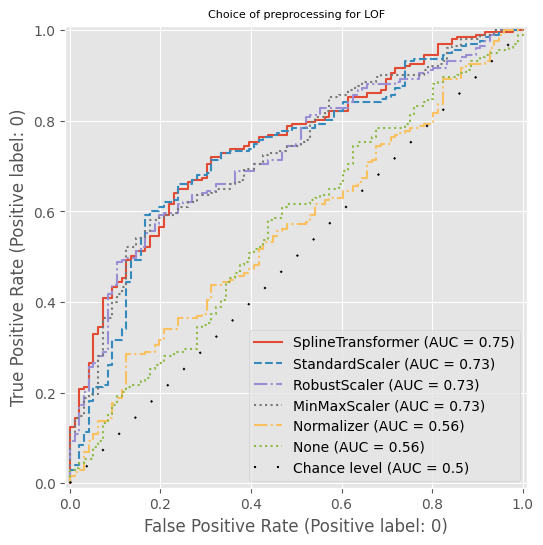

In [160]:
# Line styles for plotting
linestyles = ["solid", "dashed", "dashdot", "dotted", "-.", ":", (5, (10, 3))]
fig, ax = plt.subplots(figsize=(8, 6))
for idx, (best_param, linestyle) in enumerate(zip(lof_best_params_list, linestyles)):
    n_neighbors = best_param['n_neighbors']
    p = best_param['p']
    scaler = best_param['scaler']
    lof = LocalOutlierFactor(n_neighbors=n_neighbors, p=p, contamination=outlier_frac)
    model = make_pipeline(scaler, lof)
    model.fit(X)
    # make_pipeline itself doesn't directly give access to attributes like negative_outlier_factor_
    # Use model[-1] to access the last step in the pipeline in the case of LOF
    outlier_scores = model[-1].negative_outlier_factor_
    RocCurveDisplay.from_predictions(
                y_true,
                outlier_scores,
                pos_label=0,
                ax=ax,
                name=str(scaler).split("(")[0],
                plot_chance_level=(idx == len(preprocessor_list) - 1),
                chance_level_kw={"linestyle": (0, (1, 10))},
                linestyle=linestyle
            )
_ = ax.set_title("Choice of preprocessing for LOF", fontsize=8, loc='center')

#### 3.4.2. Isolation Forest

In [157]:
# List for the optimized hyperparameters across each preprocessing method
isf_best_params_list = [isf_spline_params_metric_scores[0], isf_standard_params_metric_scores[0], 
                       isf_robust_params_metric_scores[0], isf_minmax_params_metric_scores[0], 
                       isf_normalizer_params_metric_scores[0], isf_none_params_metric_scores[0]]

In [158]:
isf_best_params_list

[{'max_features': 0.6,
  'max_samples': 0.6,
  'n_estimators': 150,
  'scaler': SplineTransformer(),
  'auc_score': np.float64(0.7309113300492611)},
 {'max_features': 0.9,
  'max_samples': 0.65,
  'n_estimators': 100,
  'scaler': StandardScaler(),
  'auc_score': np.float64(0.7345545977011494)},
 {'max_features': 0.9,
  'max_samples': 0.65,
  'n_estimators': 100,
  'scaler': RobustScaler(),
  'auc_score': np.float64(0.7345545977011494)},
 {'max_features': 0.9,
  'max_samples': 0.65,
  'n_estimators': 100,
  'scaler': MinMaxScaler(),
  'auc_score': np.float64(0.7345545977011494)},
 {'max_features': 1.0,
  'max_samples': 0.9,
  'n_estimators': 150,
  'scaler': Normalizer(),
  'auc_score': np.float64(0.6479885057471264)},
 {'max_features': 0.9,
  'max_samples': 0.65,
  'n_estimators': 100,
  'scaler': None,
  'auc_score': np.float64(0.7345545977011494)}]

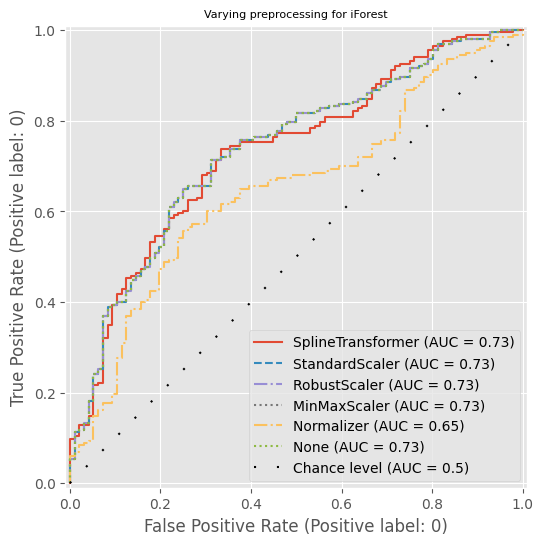

In [161]:
# Line styles for plotting
# linestyles = ["solid", "dashed", "dashdot", "dotted", "-.", ":", (5, (10, 3))]
fig, ax = plt.subplots(figsize=(8, 6))
for idx, (best_param, linestyle) in enumerate(zip(isf_best_params_list, linestyles)):
    max_features = best_param['max_features']
    max_samples = best_param['max_samples']
    n_estimators = best_param['n_estimators']
    scaler = best_param['scaler']
    isf = IsolationForest(n_estimators=n_estimators, max_samples=max_samples, contamination=outlier_frac, 
                         max_features=max_features, random_state=42, n_jobs=-1)
    model = make_pipeline(scaler, isf)
    model.fit(X)
    outlier_scores = model.decision_function(X)
    RocCurveDisplay.from_predictions(
                y_true,
                outlier_scores,
                pos_label=0,
                ax=ax,
                name=str(scaler).split("(")[0],
                plot_chance_level=(idx == len(preprocessor_list) - 1),
                chance_level_kw={"linestyle": (0, (1, 10))},
                linestyle=linestyle
            )
_ = ax.set_title("Varying preprocessing for iForest", fontsize=8, loc='center')

#### 3.4.3. One-Class SVM

In [162]:
# List for the optimized hyperparameters across each preprocessing method
svm_best_params_list = [svm_spline_params_metric_scores[0], svm_standard_params_metric_scores[0], 
                       svm_robust_params_metric_scores[0], svm_minmax_params_metric_scores[0], 
                       svm_normalizer_params_metric_scores[0], svm_none_params_metric_scores[0]]

In [163]:
svm_best_params_list

[{'gamma': 1.1,
  'kernel': 'rbf',
  'scaler': SplineTransformer(),
  'auc_score': np.float64(0.6668206075533663)},
 {'gamma': 0.1,
  'kernel': 'rbf',
  'scaler': StandardScaler(),
  'auc_score': np.float64(0.6788279967159278)},
 {'gamma': 0.1,
  'kernel': 'rbf',
  'scaler': RobustScaler(),
  'auc_score': np.float64(0.6384441707717569)},
 {'gamma': 1.5,
  'kernel': 'rbf',
  'scaler': MinMaxScaler(),
  'auc_score': np.float64(0.6841133004926108)},
 {'coef0': 1.5,
  'gamma': 2.0,
  'kernel': 'poly',
  'scaler': Normalizer(),
  'auc_score': np.float64(0.4780377668308703)},
 {'gamma': 2.0,
  'kernel': 'rbf',
  'scaler': None,
  'auc_score': np.float64(0.6397270114942528)}]

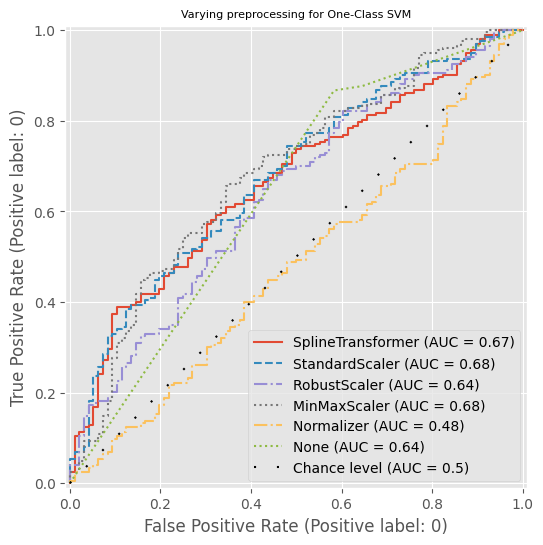

In [164]:
fig, ax = plt.subplots(figsize=(8, 6))
for idx, (best_param, linestyle) in enumerate(zip(svm_best_params_list, linestyles)):
    gamma = best_param['gamma']
    kernel = best_param['kernel']
    scaler = best_param['scaler']

    if kernel == 'rbf':
        svm = OneClassSVM(kernel=kernel, gamma=gamma, nu=outlier_frac)
    else:
        coef0 = best_param['coef0']
        svm = OneClassSVM(kernel=kernel, gamma=gamma, coef0=coef0, nu=outlier_frac)
    model = make_pipeline(scaler, svm)
    model.fit(X)
    outlier_scores = model.decision_function(X)
    RocCurveDisplay.from_predictions(
                y_true,
                outlier_scores,
                pos_label=0,
                ax=ax,
                name=str(scaler).split("(")[0],
                plot_chance_level=(idx == len(preprocessor_list) - 1),
                chance_level_kw={"linestyle": (0, (1, 10))},
                linestyle=linestyle
            )
_ = ax.set_title("Varying preprocessing for One-Class SVM", fontsize=8, loc='center')

#### 3.4.4. MCD

In [165]:
# List for the optimized hyperparameters across each preprocessing method
mcd_best_params_list = [mcd_spline_params_metric_scores[0], mcd_standard_params_metric_scores[0], 
                       mcd_robust_params_metric_scores[0], mcd_minmax_params_metric_scores[0], 
                       mcd_normalizer_params_metric_scores[0], mcd_none_params_metric_scores[0]]

In [166]:
mcd_best_params_list

[{'scaler': SplineTransformer(),
  'support_fraction': 0.825,
  'auc_score': np.float64(0.7067939244663383)},
 {'scaler': StandardScaler(),
  'support_fraction': 0.9,
  'auc_score': np.float64(0.6809831691297209)},
 {'scaler': RobustScaler(),
  'support_fraction': 0.9,
  'auc_score': np.float64(0.6809831691297209)},
 {'scaler': MinMaxScaler(),
  'support_fraction': 0.9,
  'auc_score': np.float64(0.6809831691297209)},
 {'scaler': Normalizer(),
  'support_fraction': 0.875,
  'auc_score': np.float64(0.6153530377668308)},
 {'scaler': None,
  'support_fraction': 0.9,
  'auc_score': np.float64(0.6809831691297209)}]

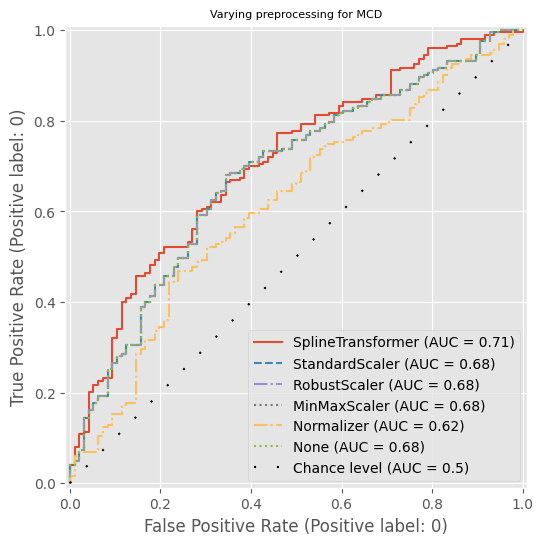

In [168]:
fig, ax = plt.subplots(figsize=(8, 6))
for idx, (best_param, linestyle) in enumerate(zip(mcd_best_params_list, linestyles)):
    support_fraction = best_param['support_fraction']
    scaler = best_param['scaler']

    mcd = EllipticEnvelope(support_fraction=support_fraction, contamination=outlier_frac, random_state=0)
    model = make_pipeline(scaler, mcd)
    model.fit(X)
    outlier_scores = model.decision_function(X)
    RocCurveDisplay.from_predictions(
                y_true,
                outlier_scores,
                pos_label=0,
                ax=ax,
                name=str(scaler).split("(")[0],
                plot_chance_level=(idx == len(preprocessor_list) - 1),
                chance_level_kw={"linestyle": (0, (1, 10))},
                linestyle=linestyle
            )
_ = ax.set_title("Varying preprocessing for MCD", fontsize=8, loc='center')

In [251]:
# # Function to assess the performance of an outlier detection model
# # across different preprocessing methods in terms of the roc curve
# # Line styles for plotting
# linestyles = ["solid", "dashed", "dashdot", "dotted", "-.", ":", (5, (10, 3))]
# def roc_auc_score_plot(X, outlier_detection_obj, outlier_detection_name):
#     fig, ax = plt.subplots(figsize=(8, 6))
#     for preprocessor_idx, (linestyle, preprocessor) in enumerate(zip(linestyles, preprocessor_list)):
#         preprocessor_name = str(preprocessor).split("(")[0]
#         model = make_pipeline(preprocessor, outlier_detection_obj)
#         model.fit(X)
#         # LOF does not have decision function when used for outlier detection
#         if outlier_detection_name == "LOF":
#             # make_pipeline itself doesn't directly give access to attributes like negative_outlier_factor_
#             # Use model[-1] to access the last step in the pipeline in the case of LOF
#             outlier_scores = model[-1].negative_outlier_factor_
#             RocCurveDisplay.from_predictions(
#                 y_true,
#                 outlier_scores,
#                 pos_label=0,
#                 ax=ax,
#                 name=preprocessor_name,
#                 plot_chance_level=(preprocessor_idx == len(preprocessor_list) - 1),
#                 chance_level_kw={"linestyle": (0, (1, 10))},
#                 linestyle=linestyle
#             )
#         else:
#             outlier_scores = model.decision_function(X)
#             RocCurveDisplay.from_predictions(
#                 y_true,
#                 outlier_scores,
#                 pos_label=0,
#                 ax=ax,
#                 name = preprocessor_name,
#                 plot_chance_level=(preprocessor_idx == len(preprocessor_list) - 1),
#                 chance_level_kw={"linestyle": (0, (1, 10))},
#                 linestyle=linestyle
#             )
#         ax.set_title(f"Varying preprocessing on {outlier_detection_name}", fontsize=12)      

#### 3.5. Outlier Prediction Labels and Scores
The best preprocessing and optimal hyperparameters identified for each of the outlier detection algorithms are used to predict  outliers in the data.

- For LOF, iForest, OneClassSVM and MCD, inliers are labeled 1, while outliers are labeled -1 according to outlier detection algorithm score.

In [169]:
# Function to return outlier prediction labels and scores for the optimal preprocessors
def model_predict(X, outlier_detection_name, outlier_detection_obj, preprocessor):
    pipeline_model = make_pipeline(preprocessor, outlier_detection_obj)
    if outlier_detection_name == 'LOF':
        # Get outlier labels and scores
        pipeline_model.fit(X)
        y_scores = pipeline_model[-1].negative_outlier_factor_
        n_features = pipeline_model[-1].n_features_in_
        offset = pipeline_model[-1].offset_
        y_pred = pipeline_model.fit_predict(X)
    elif outlier_detection_name == 'dbscan':
        pipeline_model.fit(X)
        # Get clustering labels
        y_pred = pipeline_model[-1].labels_
        y_scores = None
        n_features = None
        offset = None
    else:
        pipeline_model.fit(X)
        # Get outlier labels and scores
        n_features = pipeline_model[-1].n_features_in_
        offset = pipeline_model[-1].offset_
        y_pred = pipeline_model.predict(X)
        y_scores = pipeline_model.decision_function(X)
    # Return prediction labels and scores
    return y_pred, y_scores, n_features, offset

#### 3.5.1. Local Outlier Factor

In [170]:
lof_best_params

{'n_neighbors': np.int32(20), 'p': 1, 'scaler': SplineTransformer()}

In [171]:
optimized_lof = LocalOutlierFactor(n_neighbors=lof_best_params['n_neighbors'], p=lof_best_params['p'], 
                                   contamination=outlier_frac)

In [172]:
optimized_lof.get_params()

{'algorithm': 'auto',
 'contamination': np.float64(0.3210702341137124),
 'leaf_size': 30,
 'metric': 'minkowski',
 'metric_params': None,
 'n_jobs': None,
 'n_neighbors': np.int32(20),
 'novelty': False,
 'p': 1}

In [173]:
# Get LOF labels and scores
# Start time 
start_time = datetime.now()
y_lof_pred, y_lof_scores, lof_n_features, lof_offset = model_predict(X, 'LOF', optimized_lof, lof_best_params['scaler'])
# End time 
end_time = datetime.now()
runtime_duration = end_time - start_time
print(f"Runtime: {runtime_duration.total_seconds()} seconds")

Runtime: 0.071327 seconds


In [174]:
lof_n_features, lof_offset

(84, np.float64(-1.03640335062936))

In [175]:
y_lof_pred

array([-1, -1, -1,  1, -1, -1, -1, -1, -1, -1, -1,  1,  1,  1,  1, -1,  1,
       -1,  1, -1,  1,  1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1,  1,  1,
        1,  1, -1, -1, -1,  1, -1, -1, -1,  1,  1,  1, -1, -1, -1,  1,  1,
        1, -1,  1, -1, -1,  1,  1,  1,  1, -1, -1,  1, -1, -1, -1,  1,  1,
        1, -1,  1,  1, -1,  1,  1,  1, -1,  1, -1,  1,  1,  1,  1,  1,  1,
        1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,
        1, -1, -1, -1,  1,  1,  1, -1, -1,  1,  1,  1, -1,  1,  1, -1,  1,
        1, -1,  1,  1,  1,  1,  1, -1,  1,  1, -1, -1, -1,  1, -1, -1,  1,
        1, -1,  1,  1,  1,  1,  1,  1, -1,  1,  1,  1,  1,  1,  1,  1,  1,
        1,  1,  1,  1,  1, -1,  1,  1,  1,  1, -1, -1,  1,  1, -1,  1,  1,
        1,  1, -1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,
       -1,  1,  1,  1,  1,  1,  1,  1, -1,  1,  1,  1, -1, -1, -1,  1, -1,
        1,  1,  1,  1,  1,  1, -1, -1, -1,  1,  1,  1, -1, -1,  1,  1,  1,
        1,  1,  1,  1, -1

In [176]:
# Concatenate the labels and the scores
X_reduced_df['lof_score'] = y_lof_scores
X_reduced_df['lof_pred'] = y_lof_pred

In [177]:
X_reduced_df.head()

,PC1,PC2,y,outlier,lof_score,lof_pred
0,1641.97,-0.15,1,Yes,-1.07,-1
1,1.77,7279.25,1,Yes,-1.13,-1
2,-101358.13,-411.14,1,Yes,-1.05,-1
3,-53358.14,-457.77,1,Yes,-1.02,1
4,63641.87,-437.19,1,Yes,-1.25,-1


In [178]:
X_reduced_df.tail()

,PC1,PC2,y,outlier,lof_score,lof_pred
294,-108358.15,-494.65,0,No,-1.06,-1
295,6642.27,1236.44,0,No,-0.99,1
296,478642.32,1361.88,0,No,-1.33,-1
297,-123357.58,1861.00,0,No,-1.09,-1
298,131641.87,-417.90,0,No,-1.01,1


In [179]:
# Replace "-1" with "Yes" and "1" with "No"
X_reduced_df['lof_pred'] = X_reduced_df['lof_pred'].replace([-1, 1], ["Yes", "No"])
X_reduced_df.head()

,PC1,PC2,y,outlier,lof_score,lof_pred
0,1641.97,-0.15,1,Yes,-1.07,Yes
1,1.77,7279.25,1,Yes,-1.13,Yes
2,-101358.13,-411.14,1,Yes,-1.05,Yes
3,-53358.14,-457.77,1,Yes,-1.02,No
4,63641.87,-437.19,1,Yes,-1.25,Yes


In [180]:
X_reduced_df.tail()

,PC1,PC2,y,outlier,lof_score,lof_pred
294,-108358.15,-494.65,0,No,-1.06,Yes
295,6642.27,1236.44,0,No,-0.99,No
296,478642.32,1361.88,0,No,-1.33,Yes
297,-123357.58,1861.00,0,No,-1.09,Yes
298,131641.87,-417.90,0,No,-1.01,No


In [181]:
#X_reduced_df[['lof_score', 'lof_pred']].sort_values(by='lof_score', ascending=True)

In [182]:
# The min and the max outlier scores
round(min(X_reduced_df['lof_score']), 2), round(max(X_reduced_df['lof_score']), 2)

(-1.49, -0.95)

In [183]:
# The min outlier score of those data points predicted as inliers
round(min(X_reduced_df[X_reduced_df['lof_pred']=='No']['lof_score']), 2)

-1.04

In [184]:
# The max outlier score of those data points predicted as inliers
round(max(X_reduced_df[X_reduced_df['lof_pred']=='No']['lof_score']), 2)

-0.95

In [185]:
# The min outlier score of those data points predicted as outliers
round(min(X_reduced_df[X_reduced_df['lof_pred']=='Yes']['lof_score']), 2)

-1.49

In [186]:
# The max outlier score of those data points predicted as outliers
round(max(X_reduced_df[X_reduced_df['lof_pred']=='Yes']['lof_score']), 2)

-1.04

In [187]:
# Number of data points predicted as inliers
X_reduced_df[X_reduced_df['lof_pred']=='No'].shape[0]

203

In [188]:
# Number of data points predicted as outliers
X_reduced_df[X_reduced_df['lof_pred']=='Yes'].shape[0]

96

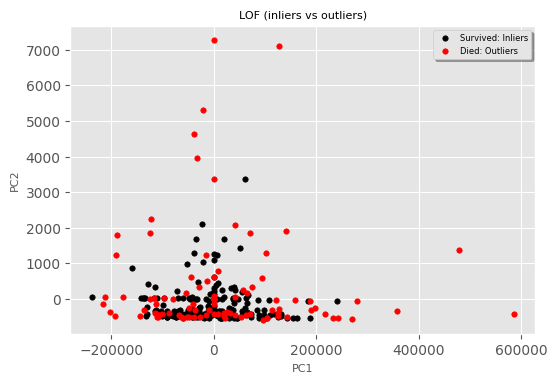

In [189]:
# 2-D scatter plot of LOF predicted outliers and scores
outlier_scatter_plot(X_reduced_df, 'lof_pred', 'LOF')

#### 3.5.2. Isolation Forest

In [190]:
isf_best_params

{'max_features': 0.9, 'max_samples': 0.65, 'n_estimators': 100, 'scaler': None}

In [191]:
optimized_isf = IsolationForest(n_estimators=isf_best_params['n_estimators'], max_samples=isf_best_params['max_samples'], 
                                contamination=outlier_frac, max_features=isf_best_params['max_features'], 
                                random_state=42, n_jobs=-1)

In [192]:
optimized_isf.get_params()

{'bootstrap': False,
 'contamination': np.float64(0.3210702341137124),
 'max_features': 0.9,
 'max_samples': 0.65,
 'n_estimators': 100,
 'n_jobs': -1,
 'random_state': 42,
 'verbose': 0,
 'warm_start': False}

In [193]:
# Get iForest labels and scores
# Start time 
start_time = datetime.now()
y_isf_pred, y_isf_scores, isf_n_features, isf_offset = model_predict(X, 'iForest', optimized_isf, isf_best_params['scaler'])
# End time 
end_time = datetime.now()
runtime_duration = end_time - start_time
print(f"Runtime: {runtime_duration.total_seconds()} seconds")

Runtime: 0.351147 seconds


In [194]:
isf_n_features, isf_offset

(12, np.float64(-0.5014307079539665))

In [195]:
y_isf_pred

array([-1, -1, -1,  1, -1, -1,  1, -1,  1, -1, -1,  1,  1,  1,  1, -1,  1,
       -1,  1, -1,  1,  1,  1,  1, -1, -1, -1,  1, -1, -1, -1, -1, -1,  1,
        1,  1, -1, -1, -1, -1, -1, -1, -1,  1, -1,  1, -1, -1, -1,  1,  1,
       -1, -1, -1, -1, -1,  1,  1, -1, -1, -1, -1,  1,  1, -1, -1, -1,  1,
        1,  1,  1,  1, -1,  1,  1,  1, -1,  1, -1,  1,  1,  1, -1, -1,  1,
        1,  1, -1,  1, -1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,
       -1, -1, -1, -1,  1,  1,  1, -1,  1,  1,  1,  1, -1,  1,  1, -1,  1,
        1, -1,  1,  1, -1,  1,  1, -1,  1,  1, -1, -1, -1,  1, -1, -1,  1,
        1,  1,  1,  1,  1,  1,  1,  1, -1,  1,  1,  1,  1,  1,  1,  1,  1,
        1,  1,  1,  1,  1,  1,  1,  1,  1,  1, -1,  1,  1,  1, -1,  1,  1,
        1,  1, -1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,
       -1,  1,  1,  1,  1,  1, -1,  1,  1,  1,  1,  1, -1, -1, -1,  1, -1,
        1,  1,  1,  1,  1, -1, -1, -1,  1, -1,  1,  1, -1, -1,  1,  1,  1,
        1,  1,  1,  1, -1

In [196]:
# Concatenate the labels and the scores
X_reduced_df['isf_score'] = y_isf_scores
X_reduced_df['isf_pred'] = y_isf_pred
X_reduced_df.head()

,PC1,PC2,y,outlier,lof_score,lof_pred,isf_score,isf_pred
0,1641.97,-0.15,1,Yes,-1.07,Yes,-0.03,-1
1,1.77,7279.25,1,Yes,-1.13,Yes,-0.03,-1
2,-101358.13,-411.14,1,Yes,-1.05,Yes,-0.01,-1
3,-53358.14,-457.77,1,Yes,-1.02,No,0.03,1
4,63641.87,-437.19,1,Yes,-1.25,Yes,-0.08,-1


In [197]:
X_reduced_df.tail()

,PC1,PC2,y,outlier,lof_score,lof_pred,isf_score,isf_pred
294,-108358.15,-494.65,0,No,-1.06,Yes,-0.03,-1
295,6642.27,1236.44,0,No,-0.99,No,0.01,1
296,478642.32,1361.88,0,No,-1.33,Yes,-0.08,-1
297,-123357.58,1861.00,0,No,-1.09,Yes,-0.04,-1
298,131641.87,-417.90,0,No,-1.01,No,0.03,1


In [198]:
# Replace "-1" with "Yes" and "1" with "No"
X_reduced_df['isf_pred'] = X_reduced_df['isf_pred'].replace([-1, 1], ["Yes", "No"])
X_reduced_df.head()

,PC1,PC2,y,outlier,lof_score,lof_pred,isf_score,isf_pred
0,1641.97,-0.15,1,Yes,-1.07,Yes,-0.03,Yes
1,1.77,7279.25,1,Yes,-1.13,Yes,-0.03,Yes
2,-101358.13,-411.14,1,Yes,-1.05,Yes,-0.01,Yes
3,-53358.14,-457.77,1,Yes,-1.02,No,0.03,No
4,63641.87,-437.19,1,Yes,-1.25,Yes,-0.08,Yes


In [199]:
X_reduced_df.tail()

,PC1,PC2,y,outlier,lof_score,lof_pred,isf_score,isf_pred
294,-108358.15,-494.65,0,No,-1.06,Yes,-0.03,Yes
295,6642.27,1236.44,0,No,-0.99,No,0.01,No
296,478642.32,1361.88,0,No,-1.33,Yes,-0.08,Yes
297,-123357.58,1861.00,0,No,-1.09,Yes,-0.04,Yes
298,131641.87,-417.90,0,No,-1.01,No,0.03,No


In [200]:
#X_reduced_df[['isf_score', 'isf_pred']].sort_values(by='isf_score', ascending=True)

In [201]:
# The min and the max outlier scores
round(min(X_reduced_df['isf_score']), 2), round(max(X_reduced_df['isf_score']), 2)

(-0.16, 0.09)

In [202]:
# The min outlier score of those data points predicted as inliers
round(min(X_reduced_df[X_reduced_df['isf_pred']=='No']['isf_score']), 2)

0.0

In [203]:
# The max outlier score of those data points predicted as inliers
round(max(X_reduced_df[X_reduced_df['isf_pred']=='No']['isf_score']), 2)

0.09

In [204]:
# The min outlier score of those data points predicted as outliers
round(min(X_reduced_df[X_reduced_df['isf_pred']=='Yes']['isf_score']), 2)

-0.16

In [205]:
# The max outlier score of those data points predicted as outliers
round(max(X_reduced_df[X_reduced_df['isf_pred']=='Yes']['isf_score']), 2)

-0.0

In [206]:
# Number of data points predicted as inliers
X_reduced_df[X_reduced_df['isf_pred']=='No'].shape[0]

203

In [207]:
# Number of data points predicted as outliers
X_reduced_df[X_reduced_df['isf_pred']=='Yes'].shape[0]

96

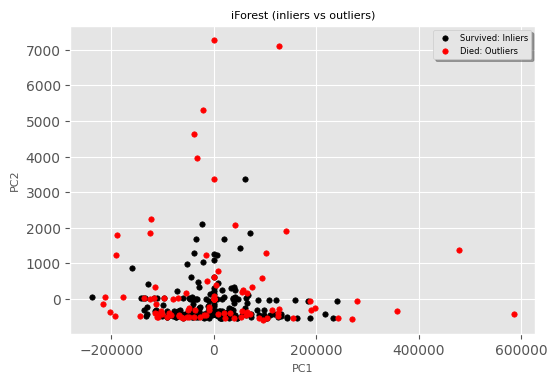

In [208]:
outlier_scatter_plot(X_reduced_df, 'isf_pred', 'iForest')

#### 3.5.3. One-Class SVM

In [209]:
svm_best_params

{'gamma': 1.5, 'kernel': 'rbf', 'scaler': MinMaxScaler()}

In [210]:
optimized_svm = OneClassSVM(kernel=svm_best_params['kernel'], gamma=svm_best_params['gamma'], 
                            nu=outlier_frac)

In [211]:
optimized_svm.get_params()

{'cache_size': 200,
 'coef0': 0.0,
 'degree': 3,
 'gamma': 1.5,
 'kernel': 'rbf',
 'max_iter': -1,
 'nu': np.float64(0.3210702341137124),
 'shrinking': True,
 'tol': 0.001,
 'verbose': False}

In [212]:
# Get one-class SVM labels and scores
# Start time 
start_time = datetime.now()
y_svm_pred, y_svm_scores, svm_n_features, svm_offset = model_predict(X, 'One-Class SVM', optimized_svm, svm_best_params['scaler'])
# End time 
end_time = datetime.now()
runtime_duration = end_time - start_time
print(f"Runtime: {runtime_duration.total_seconds()} seconds")

Runtime: 0.030301 seconds


In [213]:
svm_n_features, svm_offset

(12, array([4.65503446]))

In [214]:
y_svm_pred

array([-1, -1,  1,  1, -1, -1, -1, -1, -1, -1,  1, -1,  1,  1, -1,  1,  1,
       -1,  1, -1,  1,  1,  1, -1, -1, -1, -1, -1, -1, -1, -1, -1,  1,  1,
        1,  1, -1, -1,  1, -1,  1, -1,  1,  1,  1,  1, -1, -1, -1,  1,  1,
        1, -1,  1, -1, -1,  1,  1, -1,  1, -1,  1,  1, -1, -1,  1, -1, -1,
        1,  1,  1,  1, -1,  1,  1, -1, -1,  1, -1,  1,  1,  1,  1,  1,  1,
        1,  1, -1, -1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,
        1, -1,  1, -1,  1,  1,  1, -1, -1,  1,  1,  1,  1,  1,  1, -1,  1,
       -1,  1,  1,  1,  1,  1,  1, -1,  1,  1,  1, -1, -1,  1,  1, -1,  1,
        1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,
        1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1, -1,  1,  1,  1,  1,
        1,  1, -1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,
       -1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1, -1, -1,  1, -1,  1, -1,
       -1,  1, -1,  1,  1,  1, -1, -1, -1, -1,  1,  1, -1, -1,  1,  1,  1,
        1, -1,  1,  1, -1

In [215]:
# Concatenate the labesl and the scores
X_reduced_df['svm_score'] = y_svm_scores
X_reduced_df['svm_pred'] = y_svm_pred
X_reduced_df.head()

,PC1,PC2,y,outlier,lof_score,lof_pred,isf_score,isf_pred,svm_score,svm_pred
0,1641.97,-0.15,1,Yes,-1.07,Yes,-0.03,Yes,-0.40,-1
1,1.77,7279.25,1,Yes,-1.13,Yes,-0.03,Yes,-2.06,-1
2,-101358.13,-411.14,1,Yes,-1.05,Yes,-0.01,Yes,0.00,1
3,-53358.14,-457.77,1,Yes,-1.02,No,0.03,No,0.09,1
4,63641.87,-437.19,1,Yes,-1.25,Yes,-0.08,Yes,-1.02,-1


In [216]:
X_reduced_df.tail()

,PC1,PC2,y,outlier,lof_score,lof_pred,isf_score,isf_pred,svm_score,svm_pred
294,-108358.15,-494.65,0,No,-1.06,Yes,-0.03,Yes,-0.28,-1
295,6642.27,1236.44,0,No,-0.99,No,0.01,No,-0.00,-1
296,478642.32,1361.88,0,No,-1.33,Yes,-0.08,Yes,-1.19,-1
297,-123357.58,1861.00,0,No,-1.09,Yes,-0.04,Yes,-0.03,-1
298,131641.87,-417.90,0,No,-1.01,No,0.03,No,-0.00,-1


In [217]:
# Replace "-1" with "Yes" and "1" with "No"
X_reduced_df['svm_pred'] = X_reduced_df['svm_pred'].replace([-1, 1], ["Yes", "No"])
X_reduced_df.head()

,PC1,PC2,y,outlier,lof_score,lof_pred,isf_score,isf_pred,svm_score,svm_pred
0,1641.97,-0.15,1,Yes,-1.07,Yes,-0.03,Yes,-0.40,Yes
1,1.77,7279.25,1,Yes,-1.13,Yes,-0.03,Yes,-2.06,Yes
2,-101358.13,-411.14,1,Yes,-1.05,Yes,-0.01,Yes,0.00,No
3,-53358.14,-457.77,1,Yes,-1.02,No,0.03,No,0.09,No
4,63641.87,-437.19,1,Yes,-1.25,Yes,-0.08,Yes,-1.02,Yes


In [218]:
X_reduced_df.tail()

,PC1,PC2,y,outlier,lof_score,lof_pred,isf_score,isf_pred,svm_score,svm_pred
294,-108358.15,-494.65,0,No,-1.06,Yes,-0.03,Yes,-0.28,Yes
295,6642.27,1236.44,0,No,-0.99,No,0.01,No,-0.00,Yes
296,478642.32,1361.88,0,No,-1.33,Yes,-0.08,Yes,-1.19,Yes
297,-123357.58,1861.00,0,No,-1.09,Yes,-0.04,Yes,-0.03,Yes
298,131641.87,-417.90,0,No,-1.01,No,0.03,No,-0.00,Yes


In [219]:
#X_reduced_df[['svm_score', 'svm_pred']].sort_values(by='svm_score', ascending=True)

In [220]:
# The min and the max outlier scores
round(min(X_reduced_df['svm_score']), 2), round(max(X_reduced_df['svm_score']), 2)

(-2.57, 1.65)

In [221]:
# The min outlier score of those data points predicted as inliers
round(min(X_reduced_df[X_reduced_df['svm_pred']=='No']['svm_score']), 2)

0.0

In [222]:
# The max outlier score of those data points predicted as inliers
round(max(X_reduced_df[X_reduced_df['svm_pred']=='No']['svm_score']), 2)

1.65

In [223]:
# The min outlier score of those data points predicted as outliers
round(min(X_reduced_df[X_reduced_df['svm_pred']=='Yes']['svm_score']), 2)

-2.57

In [224]:
# The max outlier score of those data points predicted as outliers
round(max(X_reduced_df[X_reduced_df['svm_pred']=='Yes']['svm_score']), 2)

-0.0

In [225]:
# Number of data points predicted as inliers
X_reduced_df[X_reduced_df['svm_pred']=='No'].shape[0]

204

In [226]:
# Number of data points predicted as outliers
X_reduced_df[X_reduced_df['svm_pred']=='Yes'].shape[0]

95

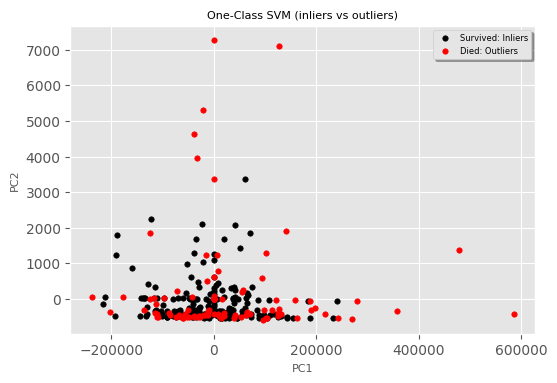

In [227]:
outlier_scatter_plot(X_reduced_df, 'svm_pred', 'One-Class SVM')

#### 3.5.4. MCD

In [228]:
mcd_best_params

{'scaler': SplineTransformer(), 'support_fraction': 0.825}

In [229]:
optimized_mcd = EllipticEnvelope(support_fraction=mcd_best_params['support_fraction'], contamination=outlier_frac, 
                                 random_state=0)

In [230]:
optimized_mcd.get_params()

{'assume_centered': False,
 'contamination': np.float64(0.3210702341137124),
 'random_state': 0,
 'store_precision': True,
 'support_fraction': 0.825}

In [231]:
# Get MCD labels and scores
# Start time 
start_time = datetime.now()
y_mcd_pred, y_mcd_scores, mcd_n_features, mcd_offset = model_predict(X, 'MCD', optimized_mcd, mcd_best_params['scaler'])
# End time 
end_time = datetime.now()
runtime_duration = end_time - start_time
print(f"Runtime: {runtime_duration.total_seconds()} seconds")

Runtime: 0.186516 seconds


In [232]:
mcd_n_features, mcd_offset

(84, np.float64(-100.05821888063943))

In [233]:
y_mcd_pred

array([-1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1,  1,  1,  1,  1, -1, -1,
       -1,  1, -1,  1,  1,  1,  1,  1,  1, -1,  1, -1, -1, -1, -1, -1,  1,
        1, -1, -1, -1, -1, -1,  1,  1,  1,  1,  1,  1, -1, -1, -1,  1,  1,
        1, -1,  1,  1, -1, -1,  1,  1,  1, -1,  1,  1, -1, -1, -1, -1,  1,
        1, -1,  1,  1, -1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,
        1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,
        1, -1,  1, -1,  1,  1,  1, -1, -1,  1,  1,  1, -1,  1,  1, -1,  1,
       -1,  1,  1,  1, -1, -1,  1, -1,  1,  1, -1,  1, -1,  1,  1, -1,  1,
        1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1, -1,  1,  1,  1,
        1,  1,  1,  1,  1, -1,  1,  1,  1, -1, -1, -1,  1,  1, -1,  1,  1,
        1, -1,  1,  1,  1,  1, -1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,
       -1,  1,  1,  1,  1,  1,  1,  1, -1,  1,  1,  1, -1, -1,  1,  1, -1,
        1,  1,  1, -1, -1,  1, -1, -1, -1,  1,  1,  1,  1, -1,  1,  1,  1,
       -1,  1,  1, -1, -1

In [234]:
# Concatenate the labels and the scores
X_reduced_df['mcd_score'] = y_mcd_scores
X_reduced_df['mcd_pred'] = y_mcd_pred
X_reduced_df.head()

,PC1,PC2,y,outlier,lof_score,lof_pred,isf_score,isf_pred,svm_score,svm_pred,mcd_score,mcd_pred
0,1641.97,-0.15,1,Yes,-1.07,Yes,-0.03,Yes,-0.40,Yes,-139.44,-1
1,1.77,7279.25,1,Yes,-1.13,Yes,-0.03,Yes,-2.06,Yes,-743.51,-1
2,-101358.13,-411.14,1,Yes,-1.05,Yes,-0.01,Yes,0.00,No,-142385.83,-1
3,-53358.14,-457.77,1,Yes,-1.02,No,0.03,No,0.09,No,-45.29,-1
4,63641.87,-437.19,1,Yes,-1.25,Yes,-0.08,Yes,-1.02,Yes,-74059372663.47,-1


In [235]:
X_reduced_df.tail()

,PC1,PC2,y,outlier,lof_score,lof_pred,isf_score,isf_pred,svm_score,svm_pred,mcd_score,mcd_pred
294,-108358.15,-494.65,0,No,-1.06,Yes,-0.03,Yes,-0.28,Yes,-416.20,-1
295,6642.27,1236.44,0,No,-0.99,No,0.01,No,-0.00,Yes,-529.43,-1
296,478642.32,1361.88,0,No,-1.33,Yes,-0.08,Yes,-1.19,Yes,-14767.78,-1
297,-123357.58,1861.00,0,No,-1.09,Yes,-0.04,Yes,-0.03,Yes,-3012.06,-1
298,131641.87,-417.90,0,No,-1.01,No,0.03,No,-0.00,Yes,-3040.57,-1


In [236]:
# Replace "-1" with "Yes" and "1" with "No"
X_reduced_df['mcd_pred'] = X_reduced_df['mcd_pred'].replace([-1, 1], ["Yes", "No"])
X_reduced_df.head()

,PC1,PC2,y,outlier,lof_score,lof_pred,isf_score,isf_pred,svm_score,svm_pred,mcd_score,mcd_pred
0,1641.97,-0.15,1,Yes,-1.07,Yes,-0.03,Yes,-0.40,Yes,-139.44,Yes
1,1.77,7279.25,1,Yes,-1.13,Yes,-0.03,Yes,-2.06,Yes,-743.51,Yes
2,-101358.13,-411.14,1,Yes,-1.05,Yes,-0.01,Yes,0.00,No,-142385.83,Yes
3,-53358.14,-457.77,1,Yes,-1.02,No,0.03,No,0.09,No,-45.29,Yes
4,63641.87,-437.19,1,Yes,-1.25,Yes,-0.08,Yes,-1.02,Yes,-74059372663.47,Yes


In [237]:
X_reduced_df.tail()

,PC1,PC2,y,outlier,lof_score,lof_pred,isf_score,isf_pred,svm_score,svm_pred,mcd_score,mcd_pred
294,-108358.15,-494.65,0,No,-1.06,Yes,-0.03,Yes,-0.28,Yes,-416.20,Yes
295,6642.27,1236.44,0,No,-0.99,No,0.01,No,-0.00,Yes,-529.43,Yes
296,478642.32,1361.88,0,No,-1.33,Yes,-0.08,Yes,-1.19,Yes,-14767.78,Yes
297,-123357.58,1861.00,0,No,-1.09,Yes,-0.04,Yes,-0.03,Yes,-3012.06,Yes
298,131641.87,-417.90,0,No,-1.01,No,0.03,No,-0.00,Yes,-3040.57,Yes


In [238]:
#X_reduced_df[['mcd_score', 'mcd_pred']].sort_values(by='mcd_score', ascending=True)

In [239]:
# The min and the max outlier scores
round(min(X_reduced_df['mcd_score']), 2), round(max(X_reduced_df['mcd_score']), 2)

(-107235397116.8, 83.24)

In [240]:
# The min outlier score of those data points predicted as inliers
round(min(X_reduced_df[X_reduced_df['mcd_pred']=='No']['mcd_score']), 2)

0.52

In [241]:
# The max outlier score of those data points predicted as inliers
round(max(X_reduced_df[X_reduced_df['mcd_pred']=='No']['mcd_score']), 2)

83.24

In [242]:
# The min outlier score of those data points predicted as outliers
round(min(X_reduced_df[X_reduced_df['mcd_pred']=='Yes']['mcd_score']), 2)

-107235397116.8

In [243]:
# The max outlier score of those data points predicted as outliers
round(max(X_reduced_df[X_reduced_df['mcd_pred']=='Yes']['mcd_score']), 2)

-1.09

In [244]:
# Number of data points predicted as inliers
X_reduced_df[X_reduced_df['mcd_pred']=='No'].shape[0]

203

In [245]:
# Number of data points predicted as outliers
X_reduced_df[X_reduced_df['mcd_pred']=='Yes'].shape[0]

96

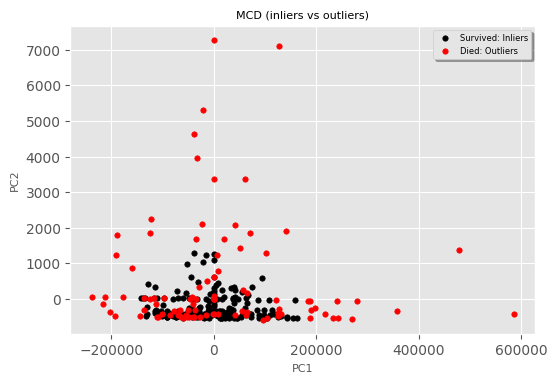

In [246]:
outlier_scatter_plot(X_reduced_df, 'mcd_pred', 'MCD')

#### 3.6. ROC Curves to Compare Performance

In [247]:
# Define lists for outlier models - names and scores
model_names = ['LOF', 'iForest', 'One-Class SVM', 'MCD']
model_score_list = [y_lof_scores, y_isf_scores, y_svm_scores, y_mcd_scores]

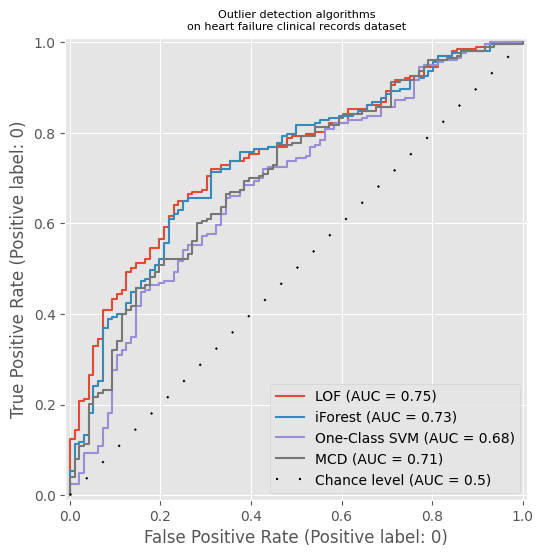

In [248]:
fig, ax = plt.subplots(figsize=(8, 6))
for idx, (model_name, model_scores) in enumerate(zip(model_names, model_score_list)):
    RocCurveDisplay.from_predictions(
    y_true,
    model_scores,
    pos_label=0,
    ax=ax,
    name=model_name,
    plot_chance_level=(idx == len(model_score_list) - 1),
    chance_level_kw={"linestyle": (0, (1, 10))}
    # linestyle=linestyle[idx]
    )
_ = ax.set_title(f"Outlier detection algorithms\non heart failure clinical records dataset", fontsize=8)


### 4. Evaluation Metrics from Confusion Matrix

In [249]:
# Define a function to return accuracy scores and confusion matrix
def cm_accuracy_score(y_true, y_pred):
    y_pred = np.where(y_pred == -1, 1, 0)
    accuracy_score_ = accuracy_score(y_true, y_pred)
    balanced_accuracy_score_ = balanced_accuracy_score(y_true, y_pred)
    # Compute the confusion matrix
    cm_obj = confusion_matrix(y_true, y_pred)
    return accuracy_score_, balanced_accuracy_score_, cm_obj

In [250]:
# Function to calculate evaluation metrics derived from confusion matrix
def metrics_from_confusion_matrix(confusion_matrix_obj):
    # Get the values from confusion matrix
    TP = confusion_matrix_obj[0, 0]
    FP = confusion_matrix_obj[1, 0]
    FN = confusion_matrix_obj[0, 1]
    TN = confusion_matrix_obj[1, 1]

    # Compute TPR, TNR, PPV, NPV
    TPR = TP / (TP + FN)
    TNR = TN / (TN + FP)
    PPV = TP / (TP + FP)
    NPV = TN / (TN + FN)

    return print(f"TP: {TP}, FP: {FP}, FN: {FN}, TN: {TN}\nTPR: {round(TPR, 4)}, TNR: {round(TNR, 4)}, PPV: {round(PPV, 4)}, NPV: {round(NPV, 4)}")


#### 4.1. Local Outlier Factor Evaluation

In [251]:
# Get the accuracy scores and confusion matrix object
lof_accuracy_score, lof_balanced_accuracy_score, lof_cm_obj = cm_accuracy_score(y_true, y_lof_pred)

In [252]:
# Print the percent prediction accuracy
print(str(round(lof_accuracy_score*100, 2)) + ' %')
print(str(round(lof_balanced_accuracy_score*100, 2)) + ' %')

69.23 %
64.71 %


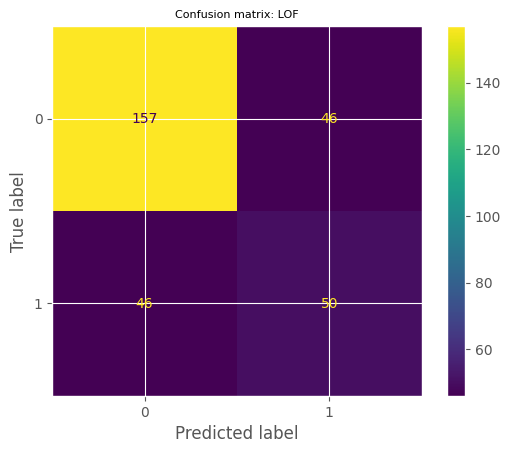

In [253]:
# Display confusion matrix
lof_disp = ConfusionMatrixDisplay(lof_cm_obj)
lof_disp.plot()
plt.title("Confusion matrix: LOF", fontsize=8)
plt.show()

In [254]:
# Get the calculated metrics
metrics_from_confusion_matrix(lof_cm_obj)

TP: 157, FP: 46, FN: 46, TN: 50
TPR: 0.7734, TNR: 0.5208, PPV: 0.7734, NPV: 0.5208


#### 4.2. Isolation Forest Evaluation

In [255]:
# Get the accuracy scores and confusion matrix object
isf_accuracy_score, isf_balanced_accuracy_score, isf_cm_obj = cm_accuracy_score(y_true, y_isf_pred)

In [256]:
# Print the percent prediction accuracy
print(str(round(isf_accuracy_score*100, 2)) + ' %')
print(str(round(isf_balanced_accuracy_score*100, 2)) + ' %')

69.9 %
65.48 %


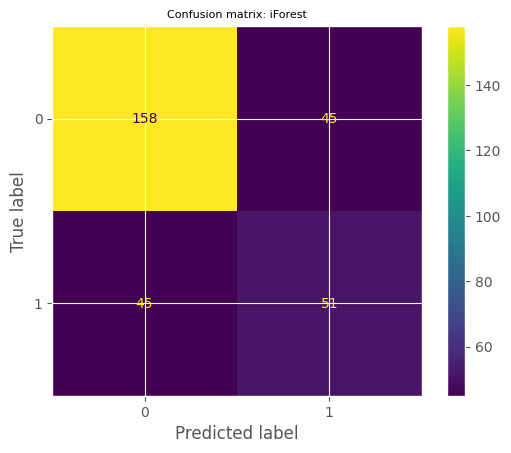

In [257]:
# Display confusion matrix
isf_disp = ConfusionMatrixDisplay(isf_cm_obj)
isf_disp.plot()
plt.title("Confusion matrix: iForest", fontsize=8)
plt.show()

In [258]:
# Get the calculated metrics
metrics_from_confusion_matrix(isf_cm_obj)

TP: 158, FP: 45, FN: 45, TN: 51
TPR: 0.7783, TNR: 0.5312, PPV: 0.7783, NPV: 0.5312


#### 4.3. One-Class SVM Evaluation

In [259]:
# Get the accuracy scores and confusion matrix object
svm_accuracy_score, svm_balanced_accuracy_score, svm_cm_obj = cm_accuracy_score(y_true, y_svm_pred)

In [260]:
# Print the percent prediction accuracy
print(str(round(svm_accuracy_score*100, 2)) + ' %')
print(str(round(svm_balanced_accuracy_score*100, 2)) + ' %')

66.22 %
61.12 %


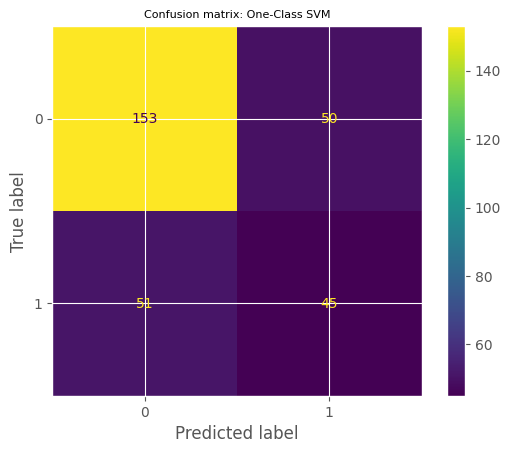

In [261]:
# Display confusion matrix
svm_disp = ConfusionMatrixDisplay(svm_cm_obj)
svm_disp.plot()
plt.title("Confusion matrix: One-Class SVM", fontsize=8)
plt.show()

In [262]:
# Get the calculated metrics
metrics_from_confusion_matrix(svm_cm_obj)

TP: 153, FP: 51, FN: 50, TN: 45
TPR: 0.7537, TNR: 0.4688, PPV: 0.75, NPV: 0.4737


#### 4.4. MCD Evaluation

In [263]:
# Get the accuracy scores and confusion matrix object
mcd_accuracy_score, mcd_balanced_accuracy_score, mcd_cm_obj = cm_accuracy_score(y_true, y_mcd_pred)

In [264]:
# Print the percent prediction accuracy
print(str(round(mcd_accuracy_score*100, 2)) + ' %')
print(str(round(mcd_balanced_accuracy_score*100, 2)) + ' %')

69.23 %
64.71 %


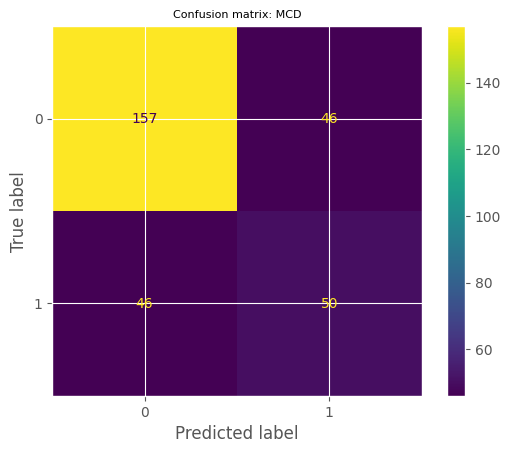

In [265]:
# Display confusion matrix
mcd_disp = ConfusionMatrixDisplay(mcd_cm_obj)
mcd_disp.plot()
plt.title("Confusion matrix: MCD", fontsize=8)
plt.show()

In [266]:
# Get the calculated metrics
metrics_from_confusion_matrix(mcd_cm_obj)

TP: 157, FP: 46, FN: 46, TN: 50
TPR: 0.7734, TNR: 0.5208, PPV: 0.7734, NPV: 0.5208


### 5. Use PCA with Outlier Detection Algorithms
When using PCA, the data is centered, but not scaled. This means that each featured is centered to have a mean of zero and variance preserved.<br/>
The data is scaled first before applying PCA to give equal importance to all the features and improve model performance

#### 5.1. Use Local Outlier Factor with PCA

In [350]:
pca_lof_best_rocauc_score = -1
pca_lof_best_params = {}
pca_lof_params_metric_scores = []

# Start time 
#start_time = datetime.now()
# n_components 2 to 8
for n_components in range(2, 9):  
    for params in lof_param_grid:
        scaler = params['scaler']
        n_neighbors = params['n_neighbors']
        p = params['p']
        
        lof = LocalOutlierFactor(n_neighbors=n_neighbors, p=p, contamination=outlier_frac, n_jobs=-1)
    
        if scaler is None:
            model = make_pipeline(PCA(n_components=n_components), lof)
        else:
            model = make_pipeline(scaler, PCA(n_components=n_components), lof)
            
        model.fit(X)
        y_scores = model[-1].negative_outlier_factor_
        fpr, tpr, thresholds = roc_curve(y_true, y_scores, pos_label=0)
        auc_score = auc(fpr, tpr)
        #params = {'scaler': scaler, 'n_neighbors': n_neighbors, 'p': p}
        # Add new key-value pair using dictionary unpacking
        pca_lof_params_metric_scores.append({**params, 'auc_score': auc_score})
        
        if auc_score > pca_lof_best_rocauc_score:
            pca_lof_best_rocauc_score = auc_score
            pca_lof_best_params = params
    print(f"PCA n_components: {n_components}")
    print(f"LOF best rocauc score: {pca_lof_best_rocauc_score}")
    print(f"LOF best parameters: {pca_lof_best_params}")
    print("----------------------------------------------------------------")

# End time 
# end_time = datetime.now()
# runtime_duration = end_time - start_time
#print(f"Runtime: {runtime_duration.total_seconds()} seconds")
# print(f"LOF best rocauc score: {lof_best_rocauc_score}")
# print(f"LOF best parameters: {lof_best_params}")

PCA n_components: 2
LOF best rocauc score: 0.6438321018062396
LOF best parameters: {'n_neighbors': 104, 'p': 2, 'scaler': RobustScaler()}
----------------------------------------------------------------
PCA n_components: 3
LOF best rocauc score: 0.6577380952380953
LOF best parameters: {'n_neighbors': 149, 'p': 1, 'scaler': RobustScaler()}
----------------------------------------------------------------
PCA n_components: 4
LOF best rocauc score: 0.6733374384236452
LOF best parameters: {'n_neighbors': 149, 'p': 1, 'scaler': RobustScaler()}
----------------------------------------------------------------
PCA n_components: 5
LOF best rocauc score: 0.6911432676518883
LOF best parameters: {'n_neighbors': 29, 'p': 2, 'scaler': StandardScaler()}
----------------------------------------------------------------
PCA n_components: 6
LOF best rocauc score: 0.7133620689655172
LOF best parameters: {'n_neighbors': 20, 'p': 2, 'scaler': RobustScaler()}
--------------------------------------------------

In [87]:
pca_lof_params_metric_scores.sort(key=lambda x: x['auc_score'], reverse=True)

In [88]:
pca_lof_params_metric_scores[:10]

[{'n_neighbors': 149,
  'p': 1,
  'scaler': StandardScaler(),
  'auc_score': 0.7393267651888341},
 {'n_neighbors': 134,
  'p': 1,
  'scaler': StandardScaler(),
  'auc_score': 0.7385570607553366},
 {'n_neighbors': 104,
  'p': 1,
  'scaler': StandardScaler(),
  'auc_score': 0.734965106732348},
 {'n_neighbors': 29,
  'p': 1,
  'scaler': StandardScaler(),
  'auc_score': 0.7320402298850575},
 {'n_neighbors': 96,
  'p': 1,
  'scaler': StandardScaler(),
  'auc_score': 0.7316810344827585},
 {'n_neighbors': 134,
  'p': 1,
  'scaler': StandardScaler(),
  'auc_score': 0.7307060755336616},
 {'n_neighbors': 149,
  'p': 1,
  'scaler': StandardScaler(),
  'auc_score': 0.7295771756978653},
 {'n_neighbors': 104,
  'p': 2,
  'scaler': StandardScaler(),
  'auc_score': 0.7253181444991791},
 {'n_neighbors': 96,
  'p': 2,
  'scaler': StandardScaler(),
  'auc_score': 0.7242405582922825},
 {'n_neighbors': 104,
  'p': 1,
  'scaler': StandardScaler(),
  'auc_score': 0.7235734811165844}]

In [89]:
len(pca_lof_params_metric_scores)

588

#### 5.2. Use Isolation Forest with PCA

In [81]:
pca_isf_best_rocauc_score = -1
pca_isf_best_params = {}
pca_isf_params_metric_scores = []
n_components = 2
# Start time 
start_time = datetime.now()

for params in isf_param_grid:
        scaler = params['scaler']
        n_estimators = params['n_estimators']
        max_samples = params['max_samples']
        max_features = params['max_features']
        isf = IsolationForest(n_estimators=n_estimators, max_samples=max_samples, contamination=outlier_frac, 
                              max_features=max_features, random_state=42, n_jobs=-1)
    
        if scaler is None:
            model = make_pipeline(PCA(n_components=n_components), isf)
        else:
            model = make_pipeline(scaler, PCA(n_components=n_components), isf)
            
        model.fit(X)
        y_scores = model.decision_function(X)
        fpr, tpr, thresholds = roc_curve(y_true, y_scores, pos_label=0)
        auc_score = auc(fpr, tpr)
        # Add new key-value pair using dictionary unpacking
        pca_isf_params_metric_scores.append({**params, 'auc_score': auc_score})
        
        if auc_score > pca_isf_best_rocauc_score:
            pca_isf_best_rocauc_score = auc_score
            pca_isf_best_params = params

# End time 
end_time = datetime.now()
runtime_duration = end_time - start_time
print(f"PCA n_components: {n_components}")
print(f"iForest best rocauc score: {pca_isf_best_rocauc_score}")
print(f"iForest best parameters: {pca_isf_best_params}")
#print("----------------------------------------------------------------")

PCA n_components: 2
IForest best rocauc score: 0.6391625615763546
IForest best parameters: {'max_features': 0.6, 'max_samples': 0.7, 'n_estimators': 100, 'scaler': StandardScaler()}


In [83]:
pca_isf_best_rocauc_score = -1
pca_isf_best_params = {}
pca_isf_params_metric_scores = []

# Start time 
start_time = datetime.now()
# n_components 2 to 8
for n_components in range(6, 9):
    for params in isf_param_grid:
        scaler = params['scaler']
        n_estimators = params['n_estimators']
        max_samples = params['max_samples']
        max_features = params['max_features']
        isf = IsolationForest(n_estimators=n_estimators, max_samples=max_samples, contamination=outlier_frac, 
                              max_features=max_features, random_state=42, n_jobs=-1)
    
        if scaler is None:
            model = make_pipeline(PCA(n_components=n_components), isf)
        else:
            model = make_pipeline(scaler, PCA(n_components=n_components), isf)
            
        model.fit(X)
        y_scores = model.decision_function(X)
        fpr, tpr, thresholds = roc_curve(y_true, y_scores, pos_label=0)
        auc_score = auc(fpr, tpr)
        # Add new key-value pair using dictionary unpacking
        pca_isf_params_metric_scores.append({**params, 'auc_score': auc_score})
        
        if auc_score > pca_isf_best_rocauc_score:
            pca_isf_best_rocauc_score = auc_score
            pca_isf_best_params = params
    print(f"PCA n_components: {n_components}")
    print(f"iForest best rocauc score: {pca_isf_best_rocauc_score}")
    print(f"iForest best parameters: {pca_isf_best_params}")
    print("----------------------------------------------------------------")

#End time 
end_time = datetime.now()
runtime_duration = end_time - start_time
print(f"Runtime: {runtime_duration.total_seconds()} seconds")

PCA n_components: 3
IForest best rocauc score: 0.6264880952380952
IForest best parameters: {'max_features': 1.0, 'max_samples': 0.7, 'n_estimators': 400, 'scaler': None}
----------------------------------------------------------------
PCA n_components: 4
IForest best rocauc score: 0.6732348111658456
IForest best parameters: {'max_features': 1.0, 'max_samples': 0.8, 'n_estimators': 100, 'scaler': None}
----------------------------------------------------------------
PCA n_components: 5
IForest best rocauc score: 0.701559934318555
IForest best parameters: {'max_features': 1.0, 'max_samples': 'auto', 'n_estimators': 150, 'scaler': None}
----------------------------------------------------------------
PCA n_components: 6
IForest best rocauc score: 0.7073583743842365
IForest best parameters: {'max_features': 0.8, 'max_samples': 0.6, 'n_estimators': 150, 'scaler': RobustScaler()}
----------------------------------------------------------------
PCA n_components: 7
IForest best rocauc score: 0

#### 5.3. Use One-Class SVM with PCA

In [ ]:
pca_svm_best_rocauc_score = -1
pca_svm_best_params = {}
pca_svm_params_metric_scores = []

# Start time 
start_time = datetime.now()
# n_components 2 to 8
for n_components in range(8, 9):
    for params in svm_param_grid:
        scaler = params['scaler']
        kernel = params['kernel']
        gamma = params['gamma']
       
        if kernel == 'rbf':
            coef0 = None
             # Since the proportion of outliers in the data is known, nu=outlier_frac
            svm = OneClassSVM(kernel=kernel, gamma=gamma, nu=outlier_frac)
        else:
            coef0 = params['coef0']
            svm = OneClassSVM(kernel=kernel, gamma=gamma, coef0=coef0, nu=outlier_frac)
    
        if scaler is None:
            model = make_pipeline(PCA(n_components=n_components), svm)
        else:
            model = make_pipeline(scaler, PCA(n_components=n_components), svm)
            
        model.fit(X)
        y_scores = model.decision_function(X)
        fpr, tpr, thresholds = roc_curve(y_true, y_scores, pos_label=0)
        auc_score = auc(fpr, tpr)
        # Add new key-value pair using dictionary unpacking
        pca_svm_params_metric_scores.append({**params, 'auc_score': auc_score})
        
        if auc_score > pca_svm_best_rocauc_score:
            pca_svm_best_rocauc_score = auc_score
            pca_svm_best_params = params
    print(f"PCA n_components: {n_components}")
    print(f"OneClassSVM best rocauc score: {pca_svm_best_rocauc_score}")
    print(f"OneClassSVM best parameters: {pca_svm_best_params}")
    print("----------------------------------------------------------------")
    
# End time 
end_time = datetime.now()
runtime_duration = end_time - start_time
print(f"Runtime: {runtime_duration.total_seconds()} seconds")

#### 5.4. Use MCD with PCA

In [67]:
pca_mcd_best_rocauc_score = -1
pca_mcd_best_params = {}
pca_mcd_params_metric_scores = []

# Start time 
start_time = datetime.now()
# n_components 2 to 8
for n_components in range(2, 9):
    for params in mcd_param_grid:
        scaler = params['scaler']
        support_fraction = params['support_fraction']
    
        mcd = EllipticEnvelope(support_fraction=support_fraction, contamination=outlier_frac, random_state=0)
    
        if scaler is None:
            model = make_pipeline(PCA(n_components=n_components), mcd)
        else:
            model = make_pipeline(scaler, PCA(n_components=n_components), mcd)
            
        model.fit(X)
        y_scores = model.decision_function(X)
        fpr, tpr, thresholds = roc_curve(y_true, y_scores, pos_label=0)
        auc_score = auc(fpr, tpr)
        #params = {'scaler': scaler, 'support_fraction': support_fraction}
        # Add new key-value pair using dictionary unpacking
        pca_mcd_params_metric_scores.append({**params, 'auc_score': auc_score})
        
        if auc_score > pca_mcd_best_rocauc_score:
            pca_mcd_best_rocauc_score = auc_score
            pca_mcd_best_params = params
    print(f"PCA n_components: {n_components}")
    print(f"MCD best rocauc score: {pca_mcd_best_rocauc_score}")
    print(f"MCD best parameters: {pca_mcd_best_params}")
    print("----------------------------------------------------------------")

#End time 
end_time = datetime.now()
runtime_duration = end_time - start_time
print(f"Runtime: {runtime_duration.total_seconds()} seconds")

PCA n_components: 2
MCD best rocauc score: 0.635929802955665
MCD best parameters: {'scaler': StandardScaler(), 'support_fraction': None}
----------------------------------------------------------------
PCA n_components: 3
MCD best rocauc score: 0.635929802955665
MCD best parameters: {'scaler': StandardScaler(), 'support_fraction': None}
----------------------------------------------------------------
PCA n_components: 4
MCD best rocauc score: 0.6548132183908046
MCD best parameters: {'scaler': RobustScaler(), 'support_fraction': 0.6}
----------------------------------------------------------------
PCA n_components: 5
MCD best rocauc score: 0.6705665024630543
MCD best parameters: {'scaler': StandardScaler(), 'support_fraction': 0.6}
----------------------------------------------------------------
PCA n_components: 6
MCD best rocauc score: 0.692169540229885
MCD best parameters: {'scaler': StandardScaler(), 'support_fraction': 0.6}
----------------------------------------------------------

In [68]:
pca_mcd_params_metric_scores.sort(key=lambda x: x['auc_score'], reverse=True)

In [69]:
pca_mcd_params_metric_scores[:10]

[{'scaler': StandardScaler(),
  'support_fraction': 0.9,
  'auc_score': 0.6994560755336617},
 {'scaler': StandardScaler(),
  'support_fraction': 0.85,
  'auc_score': 0.6978653530377668},
 {'scaler': StandardScaler(),
  'support_fraction': 0.8,
  'auc_score': 0.6971469622331691},
 {'scaler': StandardScaler(),
  'support_fraction': 0.875,
  'auc_score': 0.6970443349753693},
 {'scaler': StandardScaler(),
  'support_fraction': 0.825,
  'auc_score': 0.6969417077175698},
 {'scaler': StandardScaler(),
  'support_fraction': 0.6,
  'auc_score': 0.696274630541872},
 {'scaler': StandardScaler(),
  'support_fraction': 0.75,
  'auc_score': 0.6948378489326765},
 {'scaler': StandardScaler(),
  'support_fraction': 0.725,
  'auc_score': 0.69376026272578},
 {'scaler': StandardScaler(),
  'support_fraction': 0.6,
  'auc_score': 0.692169540229885},
 {'scaler': StandardScaler(),
  'support_fraction': 0.7,
  'auc_score': 0.6920669129720854}]

In [70]:
len(pca_mcd_params_metric_scores)

462

### 6. DBSCAN

#### 6.1. Determine Epsilon and MinPts

In [267]:
# Function to plot k-distance graph
def k_distance_plot(X_scaled, scaler_name, n_neighbors):
    neighbors = NearestNeighbors(n_neighbors=n_neighbors)
    neighbors_fit = neighbors.fit(X_scaled)
    dists, indices = neighbors_fit.kneighbors(X_scaled)
    dists = np.sort(dists, axis=0)
    # print(dists[:, 1])
    dists = dists[:, 1]
    plt.plot(dists, label=scaler_name)

In [268]:
# Define scaling methods
scalers = {
    'StandardScaler': StandardScaler(),
    'MinMaxScaler': MinMaxScaler(),
    'RobustScaler': RobustScaler(),
    'SplineTransformer': SplineTransformer(),
    'Normalizer': Normalizer()
}

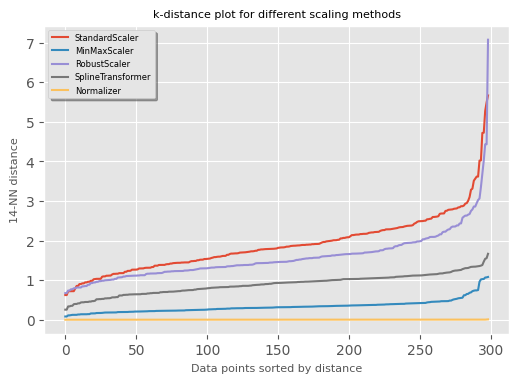

In [269]:
# k-distance plots
plt.figure(figsize=(6, 4))
for scaler_name, scaler in scalers.items():
    X_scaled = scaler.fit_transform(X)
    k_distance_plot(X_scaled, scaler_name, 14)
    
plt.xlabel('Data points sorted by distance', fontsize=8)
plt.ylabel('14-NN distance', fontsize=8)
plt.title('k-distance plot for different scaling methods', fontsize=8)
plt.legend(shadow=True, fontsize=6)
plt.show()

#### 6.2. Hyperparameter Optimization

In [270]:
# Compose dbscan parameter values
eps_values = [i / 10 for i in range(8, 33, 1)] # 0.8 to 3.1 inclusive
min_samples_values = [*range(13, 27, 1)] # 13 to 25 inclusive

In [271]:
eps_values

[0.8,
 0.9,
 1.0,
 1.1,
 1.2,
 1.3,
 1.4,
 1.5,
 1.6,
 1.7,
 1.8,
 1.9,
 2.0,
 2.1,
 2.2,
 2.3,
 2.4,
 2.5,
 2.6,
 2.7,
 2.8,
 2.9,
 3.0,
 3.1,
 3.2]

In [272]:
min_samples_values

[13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24, 25, 26]

In [273]:
# dbscan_params = { 'scaler': [ MinMaxScaler(), SplineTransformer(), StandardScaler(), RobustScaler()], 'eps': eps_values, 'min_samples': min_samples_values }
# # Define parameter grid
# dbscan_param_grid = ParameterGrid(dbscan_params)

In [274]:
dbscan_params = { 'scaler': preprocessor_list, 'eps': eps_values, 'min_samples': min_samples_values }
# Define parameter grid
dbscan_param_grid = ParameterGrid(dbscan_params)

In [275]:
len(list(dbscan_param_grid))

2100

In [276]:
# Function for tuning DBSCAN hyperparameters
def dbscan_params_search(X, y_pred, param_grid, n_components):
    dbscan_best_score = -1
    dbscan_best_params = {}
    dbscan_params_metric_scores = []
    #score_list = []
    #counter = 1440
    if n_components is None:
        for params in param_grid:
            eps = params['eps']
            min_samples = params['min_samples']
            scaler = params['scaler']
            #X_scaled = scaler.fit_transform(X)
            dbscan_obj = DBSCAN(eps=eps, min_samples=min_samples)
            model = make_pipeline(scaler, dbscan_obj)
            model.fit(X)
            # dbscan = dbscan_obj.fit(X_scaled)           
            dbscan_labels = model[-1].labels_ 
            
            # Make sure the dbscan produces at least 2 unique labels and noise (outliers)
            if len(set(dbscan_labels)) > 1 and list(dbscan_labels).count(-1) > 0:                
                # Convert dbscan labels to binary labels
                y_pred = np.where(dbscan_labels == -1, 1, 0)
                # Use binary classifier metric since dbscan is used as an outlier detection technique here
                # Balance accuracy is easy to interpret, value between 0 and 1
                score = balanced_accuracy_score(y_true, y_pred)               
                dbscan_params_metric_scores.append({**params, 'balanced_accuracy_score': score})
                if score > dbscan_best_score:
                    dbscan_best_score = score
                    dbscan_best_params = params
                    # Points labeled as -1 by DBSCAN are considered noise (outliers)
                    dbscan_best_clusters = len(set(dbscan_labels)) - (1 if -1 in dbscan_labels else 0)
                    dbscan_best_outliers = list(dbscan_labels).count(-1)
            
    else:
        for params in param_grid:
            eps=params['eps']
            min_samples = params['min_samples']
            scaler = params['scaler']
            # X_scaled = scaler.fit_transform(X)
            # X_pca = PCA(n_components=n_components).fit_transform(X_scaled)
            PCA_obj = PCA(n_components=n_components)
            dbscan_obj = DBSCAN(eps=eps, min_samples=min_samples)
            model = make_pipeline(scaler, PCA_obj, dbscan_obj)
            model.fit(X)
            dbscan_labels = model[-1].labels_
            # dbscan = dbscan_obj.fit(X_pca)
            # dbscan_labels = dbscan.labels_
            # Make sure the dbscan produces at least 2 unique labels and noise (outliers)
            if len(set(dbscan_labels)) > 1 and list(dbscan_labels).count(-1) > 0:               
                # Convert dbscan labels to binary labels
                y_pred = np.where(dbscan_labels == -1, 1, 0)
                # Use binary classifier metric since dbscan is used as an outlier detection technique
                # Balance accuracy is easy to interpret, value between 0 and 1
                score = balanced_accuracy_score(y_true, y_pred)
                dbscan_params_metric_scores.append({**params, 'balanced_accuracy_score': score})              
                if score > dbscan_best_score:
                    dbscan_best_score = score
                    dbscan_best_params = params
                    # Points labeled as -1 by DBSCAN are considered noise (outliers)
                    dbscan_best_clusters = len(set(dbscan_labels)) - (1 if -1 in dbscan_labels else 0)
                    dbscan_best_outliers = list(dbscan_labels).count(-1)

    return dbscan_best_score, dbscan_best_params, dbscan_best_clusters, dbscan_best_outliers, dbscan_params_metric_scores



In [277]:
# Start time 
start_time = datetime.now()
dbscan_best_score, dbscan_best_params, dbscan_best_clusters, dbscan_best_outliers, dbscan_params_metric_scores = dbscan_params_search(X, y_true, dbscan_param_grid, None)
# End time 
end_time = datetime.now()
runtime_duration = end_time - start_time
print(f"Runtime: {runtime_duration.total_seconds()} seconds")

Runtime: 20.40386 seconds


In [278]:
dbscan_best_score, dbscan_best_params

(np.float64(0.6957614942528736),
 {'eps': 1.8, 'min_samples': 14, 'scaler': RobustScaler()})

In [279]:
dbscan_best_clusters, dbscan_best_outliers

(1, 151)

In [280]:
dbscan_params_metric_scores.sort(key=lambda x: x['balanced_accuracy_score'], reverse=True)

In [281]:
dbscan_params_metric_scores[:10]

[{'eps': 1.8,
  'min_samples': 14,
  'scaler': RobustScaler(),
  'balanced_accuracy_score': np.float64(0.6957614942528736)},
 {'eps': 1.8,
  'min_samples': 13,
  'scaler': RobustScaler(),
  'balanced_accuracy_score': np.float64(0.6765445402298851)},
 {'eps': 1.8,
  'min_samples': 15,
  'scaler': RobustScaler(),
  'balanced_accuracy_score': np.float64(0.6763392857142857)},
 {'eps': 1.8,
  'min_samples': 16,
  'scaler': RobustScaler(),
  'balanced_accuracy_score': np.float64(0.6670515188834154)},
 {'eps': 1.9,
  'min_samples': 26,
  'scaler': RobustScaler(),
  'balanced_accuracy_score': np.float64(0.6588156814449918)},
 {'eps': 1.9,
  'min_samples': 25,
  'scaler': RobustScaler(),
  'balanced_accuracy_score': np.float64(0.6555059523809523)},
 {'eps': 1.9,
  'min_samples': 21,
  'scaler': RobustScaler(),
  'balanced_accuracy_score': np.float64(0.6507850985221675)},
 {'eps': 1.9,
  'min_samples': 20,
  'scaler': RobustScaler(),
  'balanced_accuracy_score': np.float64(0.6505028735632183)},


In [282]:
len(dbscan_params_metric_scores)

439

In [283]:
# Get the best hyperparameter values for SplineTransformer
dbscan_spline_params_metric_scores = [s for s in dbscan_params_metric_scores if str(s['scaler']) == 'SplineTransformer()']

In [284]:
dbscan_spline_params_metric_scores[:5]

[{'eps': 1.3,
  'min_samples': 17,
  'scaler': SplineTransformer(),
  'balanced_accuracy_score': np.float64(0.6367764778325122)},
 {'eps': 1.3,
  'min_samples': 19,
  'scaler': SplineTransformer(),
  'balanced_accuracy_score': np.float64(0.6305931855500821)},
 {'eps': 1.3,
  'min_samples': 18,
  'scaler': SplineTransformer(),
  'balanced_accuracy_score': np.float64(0.6296695402298851)},
 {'eps': 1.3,
  'min_samples': 20,
  'scaler': SplineTransformer(),
  'balanced_accuracy_score': np.float64(0.6257440476190476)},
 {'eps': 1.4,
  'min_samples': 26,
  'scaler': SplineTransformer(),
  'balanced_accuracy_score': np.float64(0.6249486863711002)}]

In [285]:
len(dbscan_spline_params_metric_scores)

61

In [286]:
# Get the best hyperparameter values for StandardScaler
dbscan_standard_params_metric_scores = [s for s in dbscan_params_metric_scores if str(s['scaler']) == 'StandardScaler()']

In [287]:
dbscan_standard_params_metric_scores[:5]

[{'eps': 2.7,
  'min_samples': 19,
  'scaler': StandardScaler(),
  'balanced_accuracy_score': np.float64(0.6472701149425287)},
 {'eps': 2.5,
  'min_samples': 14,
  'scaler': StandardScaler(),
  'balanced_accuracy_score': np.float64(0.6429854269293924)},
 {'eps': 2.7,
  'min_samples': 18,
  'scaler': StandardScaler(),
  'balanced_accuracy_score': np.float64(0.6400862068965517)},
 {'eps': 2.7,
  'min_samples': 17,
  'scaler': StandardScaler(),
  'balanced_accuracy_score': np.float64(0.6329022988505747)},
 {'eps': 2.6,
  'min_samples': 14,
  'scaler': StandardScaler(),
  'balanced_accuracy_score': np.float64(0.6307214696223318)}]

In [288]:
len(dbscan_standard_params_metric_scores)

117

In [289]:
# Get the best hyperparameter values for RobustScaler
dbscan_robust_params_metric_scores = [s for s in dbscan_params_metric_scores if str(s['scaler']) == 'RobustScaler()']

In [290]:
dbscan_robust_params_metric_scores[:5]

[{'eps': 1.8,
  'min_samples': 14,
  'scaler': RobustScaler(),
  'balanced_accuracy_score': np.float64(0.6957614942528736)},
 {'eps': 1.8,
  'min_samples': 13,
  'scaler': RobustScaler(),
  'balanced_accuracy_score': np.float64(0.6765445402298851)},
 {'eps': 1.8,
  'min_samples': 15,
  'scaler': RobustScaler(),
  'balanced_accuracy_score': np.float64(0.6763392857142857)},
 {'eps': 1.8,
  'min_samples': 16,
  'scaler': RobustScaler(),
  'balanced_accuracy_score': np.float64(0.6670515188834154)},
 {'eps': 1.9,
  'min_samples': 26,
  'scaler': RobustScaler(),
  'balanced_accuracy_score': np.float64(0.6588156814449918)}]

In [291]:
len(dbscan_robust_params_metric_scores)

215

In [292]:
# Get the best hyperparameter values for MinMaxScaler
dbscan_minmax_params_metric_scores = [s for s in dbscan_params_metric_scores if str(s['scaler']) == 'MinMaxScaler()']

In [293]:
dbscan_minmax_params_metric_scores[:5]

[{'eps': 0.8,
  'min_samples': 13,
  'scaler': MinMaxScaler(),
  'balanced_accuracy_score': np.float64(0.5578817733990148)},
 {'eps': 0.9,
  'min_samples': 13,
  'scaler': MinMaxScaler(),
  'balanced_accuracy_score': np.float64(0.5526734400656814)},
 {'eps': 1.0,
  'min_samples': 13,
  'scaler': MinMaxScaler(),
  'balanced_accuracy_score': np.float64(0.5474651067323482)},
 {'eps': 0.8,
  'min_samples': 14,
  'scaler': MinMaxScaler(),
  'balanced_accuracy_score': np.float64(0.5412048440065682)},
 {'eps': 0.9,
  'min_samples': 14,
  'scaler': MinMaxScaler(),
  'balanced_accuracy_score': np.float64(0.5412048440065682)}]

In [294]:
len(dbscan_minmax_params_metric_scores)

46

In [295]:
# Get the best hyperparameter values for Normalizer
dbscan_normalizer_params_metric_scores = [s for s in dbscan_params_metric_scores if str(s['scaler']) == 'Normalizer()']

In [296]:
dbscan_normalizer_params_metric_scores[:5]

[]

In [297]:
len(dbscan_normalizer_params_metric_scores)

0

In [298]:
# Get the best hyperparameter values for None
dbscan_none_params_metric_scores = [s for s in dbscan_params_metric_scores if str(s['scaler']) == 'None']

In [299]:
dbscan_none_params_metric_scores[:5]

[]

In [300]:
len(dbscan_none_params_metric_scores)

0

#### 6.3. Prediction Labels

In [301]:
# Use the optimized dbscan params to define dbscan object
optimized_dbscan = DBSCAN(eps=dbscan_best_params['eps'], min_samples=dbscan_best_params['min_samples'])

In [302]:
# Start time 
start_time = datetime.now()
y_dbscan_pred, _, _, _ = model_predict(X, 'dbscan', optimized_dbscan, dbscan_best_params['scaler'])
# End time 
end_time = datetime.now()
runtime_duration = end_time - start_time
print(f"Runtime: {runtime_duration.total_seconds()} seconds")

Runtime: 0.010507 seconds


In [303]:
y_dbscan_pred

array([-1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1,  0, -1,  0, -1, -1, -1,
       -1,  0, -1,  0, -1,  0, -1, -1, -1, -1,  0, -1, -1, -1, -1, -1,  0,
        0, -1, -1, -1, -1, -1, -1, -1, -1, -1,  0, -1, -1, -1, -1, -1,  0,
       -1, -1, -1, -1, -1, -1,  0,  0,  0, -1, -1,  0, -1, -1, -1, -1,  0,
        0, -1,  0, -1, -1, -1,  0,  0, -1,  0,  0,  0,  0,  0, -1,  0,  0,
       -1,  0,  0,  0,  0,  0,  0, -1,  0,  0,  0,  0,  0,  0,  0,  0,  0,
       -1, -1, -1, -1,  0, -1, -1, -1, -1,  0,  0, -1, -1,  0,  0, -1,  0,
       -1, -1,  0,  0,  0, -1,  0, -1,  0,  0, -1, -1, -1,  0, -1, -1,  0,
        0, -1,  0, -1, -1,  0,  0,  0, -1,  0,  0, -1, -1, -1, -1,  0,  0,
       -1,  0,  0,  0,  0, -1,  0,  0,  0, -1, -1, -1,  0, -1, -1,  0,  0,
        0, -1, -1,  0,  0,  0, -1,  0, -1,  0,  0,  0,  0, -1,  0,  0,  0,
       -1,  0,  0, -1, -1,  0,  0, -1, -1,  0,  0,  0, -1, -1, -1, -1, -1,
        0,  0,  0,  0, -1,  0,  0, -1, -1, -1,  0,  0, -1, -1, -1,  0, -1,
        0,  0, -1, -1, -1

In [304]:
# How many points labeled as outliers by dbscan
list(y_dbscan_pred).count(-1)

151

In [305]:
# Concatenate the labels
X_reduced_df['dbscan_pred'] = y_dbscan_pred
X_reduced_df.head()

,PC1,PC2,y,outlier,lof_score,lof_pred,isf_score,isf_pred,svm_score,svm_pred,mcd_score,mcd_pred,dbscan_pred
0,1641.97,-0.15,1,Yes,-1.07,Yes,-0.03,Yes,-0.40,Yes,-139.44,Yes,-1
1,1.77,7279.25,1,Yes,-1.13,Yes,-0.03,Yes,-2.06,Yes,-743.51,Yes,-1
2,-101358.13,-411.14,1,Yes,-1.05,Yes,-0.01,Yes,0.00,No,-142385.83,Yes,-1
3,-53358.14,-457.77,1,Yes,-1.02,No,0.03,No,0.09,No,-45.29,Yes,-1
4,63641.87,-437.19,1,Yes,-1.25,Yes,-0.08,Yes,-1.02,Yes,-74059372663.47,Yes,-1


In [306]:
X_reduced_df.tail()

,PC1,PC2,y,outlier,lof_score,lof_pred,isf_score,isf_pred,svm_score,svm_pred,mcd_score,mcd_pred,dbscan_pred
294,-108358.15,-494.65,0,No,-1.06,Yes,-0.03,Yes,-0.28,Yes,-416.20,Yes,-1
295,6642.27,1236.44,0,No,-0.99,No,0.01,No,-0.00,Yes,-529.43,Yes,-1
296,478642.32,1361.88,0,No,-1.33,Yes,-0.08,Yes,-1.19,Yes,-14767.78,Yes,-1
297,-123357.58,1861.00,0,No,-1.09,Yes,-0.04,Yes,-0.03,Yes,-3012.06,Yes,-1
298,131641.87,-417.90,0,No,-1.01,No,0.03,No,-0.00,Yes,-3040.57,Yes,-1


In [307]:
# Replace "-1" with "Yes" and "0" with "No" for dbscan
X_reduced_df['dbscan_pred'] = X_reduced_df['dbscan_pred'].replace([-1, 0], ["Yes", "No"])
X_reduced_df.head()

,PC1,PC2,y,outlier,lof_score,lof_pred,isf_score,isf_pred,svm_score,svm_pred,mcd_score,mcd_pred,dbscan_pred
0,1641.97,-0.15,1,Yes,-1.07,Yes,-0.03,Yes,-0.40,Yes,-139.44,Yes,Yes
1,1.77,7279.25,1,Yes,-1.13,Yes,-0.03,Yes,-2.06,Yes,-743.51,Yes,Yes
2,-101358.13,-411.14,1,Yes,-1.05,Yes,-0.01,Yes,0.00,No,-142385.83,Yes,Yes
3,-53358.14,-457.77,1,Yes,-1.02,No,0.03,No,0.09,No,-45.29,Yes,Yes
4,63641.87,-437.19,1,Yes,-1.25,Yes,-0.08,Yes,-1.02,Yes,-74059372663.47,Yes,Yes


In [308]:
X_reduced_df.tail()

,PC1,PC2,y,outlier,lof_score,lof_pred,isf_score,isf_pred,svm_score,svm_pred,mcd_score,mcd_pred,dbscan_pred
294,-108358.15,-494.65,0,No,-1.06,Yes,-0.03,Yes,-0.28,Yes,-416.20,Yes,Yes
295,6642.27,1236.44,0,No,-0.99,No,0.01,No,-0.00,Yes,-529.43,Yes,Yes
296,478642.32,1361.88,0,No,-1.33,Yes,-0.08,Yes,-1.19,Yes,-14767.78,Yes,Yes
297,-123357.58,1861.00,0,No,-1.09,Yes,-0.04,Yes,-0.03,Yes,-3012.06,Yes,Yes
298,131641.87,-417.90,0,No,-1.01,No,0.03,No,-0.00,Yes,-3040.57,Yes,Yes


In [309]:
# Number of data points predicted as inliers
X_reduced_df[X_reduced_df['dbscan_pred']=='No'].shape[0]

148

In [310]:
# Number of data points predicted as outliers
X_reduced_df[X_reduced_df['dbscan_pred']=='Yes'].shape[0]

151

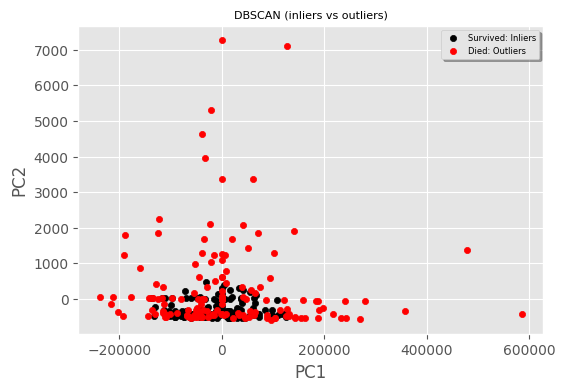

In [311]:
plt.figure(figsize=(6, 4))
plt.scatter(X_reduced_df['PC1'][X_reduced_df['dbscan_pred']=="No"], 
            X_reduced_df['PC2'][X_reduced_df['dbscan_pred']=="No"], 
            c='black',
            s=5*4,
            label='Survived: Inliers')
    
plt.scatter(X_reduced_df['PC1'][X_reduced_df['dbscan_pred']=="Yes"], 
            X_reduced_df['PC2'][X_reduced_df['dbscan_pred']=="Yes"], 
            c='red',
            s=5*4,
            label='Died: Outliers')
plt.title("DBSCAN (inliers vs outliers)", fontsize=8)
plt.legend(shadow=True, fontsize=6)
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.show()

#### 6.4. Evaluation Metrics from Confusion Matrix

In [312]:
dbscan_accuracy_score, dbscan_balanced_accuracy_score, dbscan_cm_obj = cm_accuracy_score(y_true, y_dbscan_pred)

In [313]:
# Print the percent prediction accuracy
print(str(round(dbscan_accuracy_score*100, 2)) + ' %')
print(str(round(dbscan_balanced_accuracy_score*100, 2)) + ' %')

66.89 %
69.58 %


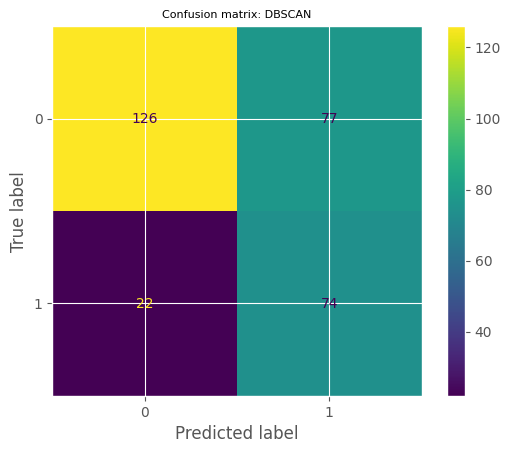

In [314]:
# Display confusion matrix
dbscan_disp = ConfusionMatrixDisplay(dbscan_cm_obj)
dbscan_disp.plot()
plt.title("Confusion matrix: DBSCAN", fontsize=8)
plt.show()

In [315]:
# Get the metrics calculated from confusion matrix
metrics_from_confusion_matrix(dbscan_cm_obj)

TP: 126, FP: 22, FN: 77, TN: 74
TPR: 0.6207, TNR: 0.7708, PPV: 0.8514, NPV: 0.4901


#### 6.5. Use PCA with DBSCAN

In [316]:
for n_components in range(2, 9):
    _, _, _, _, pca_params_metric_scores = dbscan_params_search(X, y_true, dbscan_param_grid, n_components)
    pca_params_metric_scores.sort(key=lambda x: x['balanced_accuracy_score'], reverse=True)
    print(f"n_components={n_components}: {pca_params_metric_scores[0]}")

n_components=2: {'eps': 0.8, 'min_samples': 26, 'scaler': StandardScaler(), 'balanced_accuracy_score': np.float64(0.5855911330049262)}
n_components=3: {'eps': 0.9, 'min_samples': 14, 'scaler': StandardScaler(), 'balanced_accuracy_score': np.float64(0.6459872742200329)}
n_components=4: {'eps': 0.8, 'min_samples': 13, 'scaler': RobustScaler(), 'balanced_accuracy_score': np.float64(0.6612017651888342)}
n_components=5: {'eps': 1.4, 'min_samples': 14, 'scaler': StandardScaler(), 'balanced_accuracy_score': np.float64(0.6825225779967159)}
n_components=6: {'eps': 1.6, 'min_samples': 14, 'scaler': StandardScaler(), 'balanced_accuracy_score': np.float64(0.7023039819376027)}
n_components=7: {'eps': 2.0, 'min_samples': 26, 'scaler': StandardScaler(), 'balanced_accuracy_score': np.float64(0.6968134236453202)}
n_components=8: {'eps': 2.2, 'min_samples': 21, 'scaler': StandardScaler(), 'balanced_accuracy_score': np.float64(0.6948378489326765)}


In [317]:
# Get the best params
pca_best_score, pca_best_params, pca_best_clusters, pca_best_outliers, pca_params_metric_scores = dbscan_params_search(X, y_true, dbscan_param_grid, 6)

In [318]:
pca_best_score, pca_best_clusters, pca_best_outliers

(np.float64(0.7023039819376027), 1, 139)

In [319]:
pca_params_metric_scores.sort(key=lambda x: x['balanced_accuracy_score'], reverse=True)

In [320]:
pca_params_metric_scores[:10]

[{'eps': 1.6,
  'min_samples': 14,
  'scaler': StandardScaler(),
  'balanced_accuracy_score': np.float64(0.7023039819376027)},
 {'eps': 1.6,
  'min_samples': 13,
  'scaler': StandardScaler(),
  'balanced_accuracy_score': np.float64(0.698429802955665)},
 {'eps': 1.7,
  'min_samples': 18,
  'scaler': StandardScaler(),
  'balanced_accuracy_score': np.float64(0.6978653530377668)},
 {'eps': 1.6,
  'min_samples': 15,
  'scaler': StandardScaler(),
  'balanced_accuracy_score': np.float64(0.689988711001642)},
 {'eps': 1.7,
  'min_samples': 19,
  'scaler': StandardScaler(),
  'balanced_accuracy_score': np.float64(0.6882953612479474)},
 {'eps': 1.7,
  'min_samples': 20,
  'scaler': StandardScaler(),
  'balanced_accuracy_score': np.float64(0.6833692528735633)},
 {'eps': 1.7,
  'min_samples': 17,
  'scaler': StandardScaler(),
  'balanced_accuracy_score': np.float64(0.6816759031198687)},
 {'eps': 1.7,
  'min_samples': 21,
  'scaler': StandardScaler(),
  'balanced_accuracy_score': np.float64(0.681470

In [321]:
pca_best_params

{'eps': 1.6, 'min_samples': 14, 'scaler': StandardScaler()}

In [322]:
# Get dbscan labels
pca_best_scalar = pca_best_params['scaler']
X_scaled = pca_best_scalar.fit_transform(X)
X_pca = PCA(n_components=6).fit_transform(X_scaled)
pca_dbscan_obj = DBSCAN(eps=pca_best_params['eps'], min_samples=pca_best_params['min_samples'])
pca_dbscan = pca_dbscan_obj.fit(X_pca)
y_pca_dbscan_pred = pca_dbscan.labels_

In [323]:
y_pca_dbscan_pred

array([-1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1,  0, -1, -1, -1,
       -1, -1, -1, -1, -1, -1, -1, -1,  0, -1, -1, -1, -1, -1, -1, -1,  0,
        0, -1, -1, -1, -1,  0, -1, -1,  0,  0,  0,  0, -1, -1, -1,  0, -1,
       -1, -1, -1, -1, -1,  0,  0, -1, -1, -1, -1,  0,  0, -1, -1, -1,  0,
        0, -1,  0,  0, -1,  0,  0,  0, -1,  0, -1,  0,  0,  0, -1, -1, -1,
        0,  0,  0,  0, -1,  0,  0,  0, -1, -1, -1, -1, -1, -1,  0,  0,  0,
       -1, -1, -1, -1,  0,  0,  0, -1, -1,  0,  0, -1, -1,  0,  0, -1,  0,
       -1,  0,  0,  0, -1, -1,  0, -1,  0,  0,  0, -1, -1,  0, -1, -1,  0,
        0, -1,  0, -1,  0,  0,  0,  0,  0,  0,  0,  0,  0, -1, -1,  0,  0,
        0,  0,  0,  0,  0,  0, -1,  0,  0,  0, -1, -1, -1,  0, -1,  0,  0,
        0, -1, -1, -1,  0,  0,  0,  0, -1,  0,  0,  0,  0,  0,  0,  0,  0,
        0,  0,  0, -1, -1,  0,  0, -1, -1,  0,  0, -1, -1, -1, -1, -1,  0,
        0,  0,  0,  0,  0, -1, -1,  0, -1, -1,  0,  0, -1, -1,  0, -1,  0,
        0,  0, -1, -1, -1

In [324]:
list(y_pca_dbscan_pred).count(-1)

139

In [325]:
# Concatenate the labels
X_reduced_df['pca_dbscan_pred'] = y_pca_dbscan_pred
X_reduced_df.head()

,PC1,PC2,y,outlier,lof_score,lof_pred,isf_score,isf_pred,svm_score,svm_pred,mcd_score,mcd_pred,dbscan_pred,pca_dbscan_pred
0,1641.97,-0.15,1,Yes,-1.07,Yes,-0.03,Yes,-0.40,Yes,-139.44,Yes,Yes,-1
1,1.77,7279.25,1,Yes,-1.13,Yes,-0.03,Yes,-2.06,Yes,-743.51,Yes,Yes,-1
2,-101358.13,-411.14,1,Yes,-1.05,Yes,-0.01,Yes,0.00,No,-142385.83,Yes,Yes,-1
3,-53358.14,-457.77,1,Yes,-1.02,No,0.03,No,0.09,No,-45.29,Yes,Yes,-1
4,63641.87,-437.19,1,Yes,-1.25,Yes,-0.08,Yes,-1.02,Yes,-74059372663.47,Yes,Yes,-1


In [326]:
X_reduced_df.tail()

,PC1,PC2,y,outlier,lof_score,lof_pred,isf_score,isf_pred,svm_score,svm_pred,mcd_score,mcd_pred,dbscan_pred,pca_dbscan_pred
294,-108358.15,-494.65,0,No,-1.06,Yes,-0.03,Yes,-0.28,Yes,-416.20,Yes,Yes,0
295,6642.27,1236.44,0,No,-0.99,No,0.01,No,-0.00,Yes,-529.43,Yes,Yes,0
296,478642.32,1361.88,0,No,-1.33,Yes,-0.08,Yes,-1.19,Yes,-14767.78,Yes,Yes,-1
297,-123357.58,1861.00,0,No,-1.09,Yes,-0.04,Yes,-0.03,Yes,-3012.06,Yes,Yes,-1
298,131641.87,-417.90,0,No,-1.01,No,0.03,No,-0.00,Yes,-3040.57,Yes,Yes,0


In [327]:
# Replace "-1" with "Yes" and "0" with "No" for dbscan
X_reduced_df['pca_dbscan_pred'] = X_reduced_df['pca_dbscan_pred'].replace([-1, 0], ["Yes", "No"])
X_reduced_df.head()

,PC1,PC2,y,outlier,lof_score,lof_pred,isf_score,isf_pred,svm_score,svm_pred,mcd_score,mcd_pred,dbscan_pred,pca_dbscan_pred
0,1641.97,-0.15,1,Yes,-1.07,Yes,-0.03,Yes,-0.40,Yes,-139.44,Yes,Yes,Yes
1,1.77,7279.25,1,Yes,-1.13,Yes,-0.03,Yes,-2.06,Yes,-743.51,Yes,Yes,Yes
2,-101358.13,-411.14,1,Yes,-1.05,Yes,-0.01,Yes,0.00,No,-142385.83,Yes,Yes,Yes
3,-53358.14,-457.77,1,Yes,-1.02,No,0.03,No,0.09,No,-45.29,Yes,Yes,Yes
4,63641.87,-437.19,1,Yes,-1.25,Yes,-0.08,Yes,-1.02,Yes,-74059372663.47,Yes,Yes,Yes


In [328]:
X_reduced_df.tail()

,PC1,PC2,y,outlier,lof_score,lof_pred,isf_score,isf_pred,svm_score,svm_pred,mcd_score,mcd_pred,dbscan_pred,pca_dbscan_pred
294,-108358.15,-494.65,0,No,-1.06,Yes,-0.03,Yes,-0.28,Yes,-416.20,Yes,Yes,No
295,6642.27,1236.44,0,No,-0.99,No,0.01,No,-0.00,Yes,-529.43,Yes,Yes,No
296,478642.32,1361.88,0,No,-1.33,Yes,-0.08,Yes,-1.19,Yes,-14767.78,Yes,Yes,Yes
297,-123357.58,1861.00,0,No,-1.09,Yes,-0.04,Yes,-0.03,Yes,-3012.06,Yes,Yes,Yes
298,131641.87,-417.90,0,No,-1.01,No,0.03,No,-0.00,Yes,-3040.57,Yes,Yes,No


In [329]:
# Number of data points predicted as inliers
X_reduced_df[X_reduced_df['pca_dbscan_pred']=='No'].shape[0]

160

In [330]:
# Number of data points predicted as outliers
X_reduced_df[X_reduced_df['pca_dbscan_pred']=='Yes'].shape[0]

139

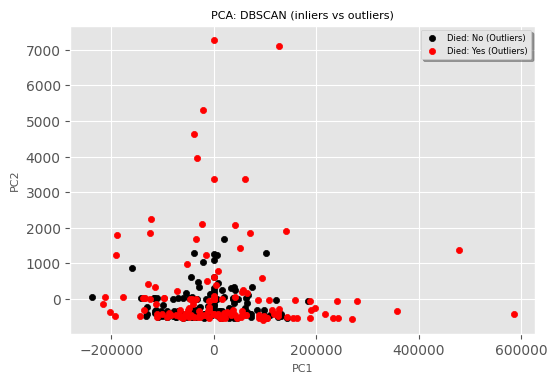

In [331]:
plt.figure(figsize=(6, 4))
plt.scatter(X_reduced_df['PC1'][X_reduced_df['pca_dbscan_pred']=="No"], 
            X_reduced_df['PC2'][X_reduced_df['pca_dbscan_pred']=="No"], 
            c='black',
            s=5*4,
            label='Died: No (Outliers)')
    
plt.scatter(X_reduced_df['PC1'][X_reduced_df['pca_dbscan_pred']=="Yes"], 
            X_reduced_df['PC2'][X_reduced_df['pca_dbscan_pred']=="Yes"], 
            c='red',
            s=5*4,
            label='Died: Yes (Outliers)')
plt.title("PCA: DBSCAN (inliers vs outliers)", fontsize=8)
plt.legend(shadow=True, fontsize=6)
plt.xlabel("PC1", fontsize=8)
plt.ylabel("PC2", fontsize=8)
plt.show()

In [332]:
pca_dbscan_accuracy_score, pca_dbscan_balanced_accuracy_score, pca_dbscan_cm_obj = cm_accuracy_score(y_true, y_pca_dbscan_pred)

In [333]:
# Print the percent prediction accuracy
print(str(round(pca_dbscan_accuracy_score*100, 2)) + ' %')
print(str(round(pca_dbscan_balanced_accuracy_score*100, 2)) + ' %')

68.9 %
70.23 %


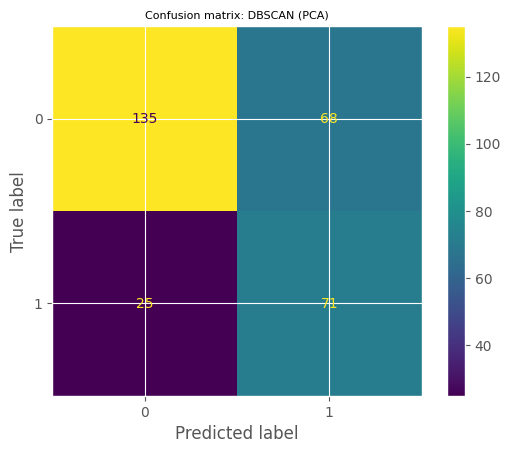

In [334]:
# Display confusion matrix
pca_dbscan_disp = ConfusionMatrixDisplay(pca_dbscan_cm_obj)
pca_dbscan_disp.plot()
plt.title("Confusion matrix: DBSCAN (PCA)", fontsize=8)
plt.show()

In [335]:
# Get the metrics calculated from confusion matrix
metrics_from_confusion_matrix(pca_dbscan_cm_obj)

TP: 135, FP: 25, FN: 68, TN: 71
TPR: 0.665, TNR: 0.7396, PPV: 0.8438, NPV: 0.5108
